In [2]:
import subprocess, sys

# Fix: upgrade torch to be compatible with numpy 2.x
print("Step 1/3: Upgrading torch...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--no-warn-script-location",
    "torch==2.4.0", "torchvision==0.19.0",
    "--index-url", "https://download.pytorch.org/whl/cu121"
])

print("Step 2/3: Installing facenet-pytorch (no-deps)...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--no-warn-script-location",
    "facenet-pytorch==2.5.3", "--no-deps"
])

print("Step 3/3: Installing timm + pillow...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--no-warn-script-location",
    "timm", "Pillow"
])

# Verify fix in fresh subprocess
check = subprocess.check_output([
    sys.executable, "-c",
    "import torch, numpy; print(torch.__version__, numpy.__version__)"
], text=True).strip()
print(f"\n✓ torch + numpy: {check}")

print("\n" + "=" * 50)
print("INSTALL COMPLETE")
print("NEXT → Kernel menu → Restart Session")
print("Then run Cell 2")
print("=" * 50)

# Auto-restart kernel
try:
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)
except Exception:
    pass

Step 1/3: Upgrading torch...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 8.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires torch<2.3.0,>=2.2.0, but you have torch 2.4.0+cu121 which is incompatible.
facenet-pytorch 2.6.0 requires torchvision<0.18.0,>=0.17.0, but you have torchvision 0.19.0+cu121 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.4.0+cu121 which is incompatible.


Step 2/3: Installing facenet-pytorch (no-deps)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.0 MB/s eta 0:00:00
Step 3/3: Installing timm + pillow...

✓ torch + numpy: 2.4.0+cu121 1.26.4

INSTALL COMPLETE
NEXT → Kernel menu → Restart Session
Then run Cell 2


In [1]:
import os, gc, cv2, random, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as tvm
import timm
from facenet_pytorch import MTCNN
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(42)

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXTRACT_DEVICE = "cpu"

# Verify the numpy bridge fix
t = torch.tensor([1.0, 2.0]).numpy()

print("=" * 55)
print("ENVIRONMENT REPORT")
print("=" * 55)
print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"numpy    : {np.__version__}")
print(f"Device   : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    free, total = torch.cuda.mem_get_info(0)
    print(f"GPU      : {props.name}")
    print(f"VRAM     : {total/1e9:.1f} GB total | {free/1e9:.2f} GB free")
print(f"numpy bridge: {t}  ← must not crash")
print("=" * 55)
print("All imports successful ✓")
print("Cell 2 complete ✓")

ENVIRONMENT REPORT
PyTorch  : 2.4.0+cu121
timm     : 1.0.25
numpy    : 1.26.4
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB total | 15.53 GB free
numpy bridge: [1. 2.]  ← must not crash
All imports successful ✓
Cell 2 complete ✓


In [3]:
import os
from pathlib import Path

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}

print("=" * 60)
print("SCANNING /kaggle/input/ ...")
print("=" * 60)

# Print full directory tree of /kaggle/input/
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 4:  # only show files up to depth 4
        for f in files:
            size = os.path.getsize(os.path.join(root, f)) / 1e6
            print(f"{indent}  {f}  ({size:.1f} MB)")

SCANNING /kaggle/input/ ...
input/
  models/
    monikaphadtare/
      deepguard-v2/
        other/
          default/
            1/
  datasets/
    monikaphadtare/
      dfd-testdata/
        fake/
        real/


In [4]:
# ── Model checkpoints ──────────────────────────────────────────
CKPT_CN = "/kaggle/input/models/monikaphadtare/deepguard-v2/other/default/1/best_convnextv2_v2.pth"
CKPT_XC = "/kaggle/input/models/monikaphadtare/deepguard-v2/other/default/1/best_xception_v3.pth"
CKPT_RN = "/kaggle/input/models/monikaphadtare/deepguard-v2/other/default/1/best_resnext_bilstm_v2.pth"

# ── Dataset root ───────────────────────────────────────────────
DATA_ROOT = Path("/kaggle/input/datasets/monikaphadtare/dfd-testdata")

# ── Per-model calibrated thresholds ───────────────────────────
THRESH_CN = 0.30   # ConvNeXt V2 v3
THRESH_XC = 0.48   # XceptionNet v3
THRESH_RN = 0.40   # ResNeXt50+BiLSTM v2

# ── Inference config ───────────────────────────────────────────
NUM_FRAMES = 15
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}
IMG_MEAN   = [0.485, 0.456, 0.406]
IMG_STD    = [0.229, 0.224, 0.225]

print("=" * 60)
print("PATH CHECK")
print("=" * 60)
for name, p in [("ConvNeXt V2",    CKPT_CN),
                ("XceptionNet",    CKPT_XC),
                ("ResNeXt+BiLSTM", CKPT_RN)]:
    exists = os.path.exists(p)
    size   = os.path.getsize(p) / 1e6 if exists else 0
    print(f"{'✓' if exists else '✗'} {name:20s}  {size:.1f} MB")

print(f"\nDataset root : {DATA_ROOT}")
real_dir = DATA_ROOT / "real"
fake_dir = DATA_ROOT / "fake"
print(f"  real/ exists : {real_dir.exists()}")
print(f"  fake/ exists : {fake_dir.exists()}")

if real_dir.exists() and fake_dir.exists():
    real_vids = sorted([f for f in real_dir.rglob("*") if f.suffix.lower() in VIDEO_EXTS])
    fake_vids = sorted([f for f in fake_dir.rglob("*") if f.suffix.lower() in VIDEO_EXTS])
    print(f"  real videos  : {len(real_vids)}")
    print(f"  fake videos  : {len(fake_vids)}")
    print(f"  total videos : {len(real_vids) + len(fake_vids)}")

print(f"\nThresholds → CN:{THRESH_CN}  XC:{THRESH_XC}  RN:{THRESH_RN}")
print("=" * 60)
print("Cell 3 complete ✓")

PATH CHECK
✓ ConvNeXt V2           353.0 MB
✓ XceptionNet           87.8 MB
✓ ResNeXt+BiLSTM        197.3 MB

Dataset root : /kaggle/input/datasets/monikaphadtare/dfd-testdata
  real/ exists : True
  fake/ exists : True
  real videos  : 10
  fake videos  : 10
  total videos : 20

Thresholds → CN:0.3  XC:0.48  RN:0.4
Cell 3 complete ✓


In [5]:
mtcnn = MTCNN(
    image_size=224, margin=20, min_face_size=20,
    thresholds=[0.5, 0.6, 0.6], factor=0.709,
    post_process=False,        # critical: keeps uint8 RGB, no black frames
    select_largest=True,
    keep_all=False,
    device=EXTRACT_DEVICE
)

def center_crop_fallback(frame_bgr, size=224):
    h, w = frame_bgr.shape[:2]
    m = min(h, w)
    y0, x0 = (h - m) // 2, (w - m) // 2
    crop = frame_bgr[y0:y0+m, x0:x0+m]
    crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

def extract_frames(video_path, num_frames=15):
    try:
        cap   = cv2.VideoCapture(str(video_path))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if not cap.isOpened() or total == 0:
            cap.release()
            return None

        indices = np.linspace(0, total - 1, num_frames, dtype=int)
        indices = np.clip(indices, 0, total - 1)
        frames  = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame_bgr = cap.read()
            if not ret:
                continue
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            pil_img   = Image.fromarray(frame_rgb)
            face      = mtcnn(pil_img)

            if face is not None:
                face_np = face.permute(1, 2, 0).numpy()
                face_np = np.clip(face_np, 0, 255).astype(np.uint8)
                frames.append(face_np)
            else:
                frames.append(center_crop_fallback(frame_bgr))

        cap.release()
        if not frames:
            return None

        while len(frames) < num_frames:
            frames.append(frames[-1])
        return frames[:num_frames]

    except Exception as e:
        print(f"  Error [{Path(video_path).name}]: {e}")
        return None

print(f"MTCNN initialized on : {EXTRACT_DEVICE}")
print("extract_frames() ready — zero rejection strategy ✓")
print("Cell 4 complete ✓")

MTCNN initialized on : cpu
extract_frames() ready — zero rejection strategy ✓
Cell 4 complete ✓


In [6]:
print("=" * 60)
print("EXTRACTING FRAMES FROM ALL VIDEOS")
print("=" * 60)

meta       = []
all_frames = []
skipped    = 0

for label_name, label_idx, vid_list in [
    ("REAL", 0, real_vids),
    ("FAKE", 1, fake_vids)
]:
    print(f"\nProcessing {label_name} videos ({len(vid_list)} total)...")
    for vp in tqdm(vid_list, desc=label_name, unit="vid"):
        frames = extract_frames(vp, num_frames=NUM_FRAMES)
        if frames is not None:
            meta.append({
                "video_id"   : Path(vp).stem,
                "video_path" : str(vp),
                "label"      : label_idx,
                "label_name" : label_name,
                "n_frames"   : len(frames),
            })
            all_frames.append(frames)
        else:
            skipped += 1
            print(f"  Skipped: {Path(vp).name}")

df_meta = pd.DataFrame(meta)

print("\n" + "=" * 60)
print("EXTRACTION COMPLETE")
print("=" * 60)
print(f"Total videos extracted : {len(df_meta)}")
print(f"Real                   : {(df_meta.label == 0).sum()}")
print(f"Fake                   : {(df_meta.label == 1).sum()}")
print(f"Skipped                : {skipped}")
print(f"Frames per video       : {NUM_FRAMES}")
print(f"Total frames           : {len(df_meta) * NUM_FRAMES}")
print("=" * 60)
print("Cell 5 complete ✓")

EXTRACTING FRAMES FROM ALL VIDEOS

Processing REAL videos (10 total)...


REAL: 100%|██████████| 10/10 [01:14<00:00,  7.47s/vid]



Processing FAKE videos (10 total)...


FAKE: 100%|██████████| 10/10 [01:23<00:00,  8.38s/vid]


EXTRACTION COMPLETE
Total videos extracted : 20
Real                   : 10
Fake                   : 10
Skipped                : 0
Frames per video       : 15
Total frames           : 300
Cell 5 complete ✓


In [7]:
# ── Model 1: ConvNeXt V2 ───────────────────────────────────────
class ConvNeXtV2Deepfake(nn.Module):
    def __init__(self, model_name="convnextv2_base", dropout=0.4,
                 drop_path_rate=0.2, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=False, num_classes=0,
            drop_rate=dropout, drop_path_rate=drop_path_rate)
        fd = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(fd), nn.Dropout(dropout),
            nn.Linear(fd, 512), nn.GELU(),
            nn.Dropout(dropout/2), nn.Linear(512, num_classes))
    def forward(self, x):
        return self.head(self.backbone(x))

# ── Model 2: XceptionNet ───────────────────────────────────────
class XceptionDeepfake(nn.Module):
    def __init__(self, model_name="legacy_xception", dropout=0.5,
                 num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=False, num_classes=0,
            drop_rate=dropout)
        fd = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(fd), nn.Dropout(dropout),
            nn.Linear(fd, 512), nn.BatchNorm1d(512), nn.GELU(),
            nn.Dropout(dropout/2), nn.Linear(512, num_classes))
    def forward(self, x):
        return self.head(self.backbone(x))

# ── Model 3: ResNeXt50 + BiLSTM ───────────────────────────────
class ResNeXtBiLSTM(nn.Module):
    def __init__(self, lstm_hidden=1024, lstm_layers=1, dropout=0.4,
                 num_classes=2, bidirectional=True):
        super().__init__()
        bb = tvm.resnext50_32x4d(
            weights=tvm.ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
        self.stem    = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1  = bb.layer1
        self.layer2  = bb.layer2
        self.layer3  = bb.layer3
        self.layer4  = bb.layer4
        self.avgpool = bb.avgpool
        self.feat_dim      = 2048
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=self.feat_dim, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=bidirectional)
        lstm_out = lstm_hidden * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.LayerNorm(lstm_out), nn.Dropout(dropout),
            nn.Linear(lstm_out, 512), nn.GELU(),
            nn.Dropout(dropout/2), nn.Linear(512, num_classes))
    def forward(self, x):
        if x.dim() == 4:
            x = x.unsqueeze(1)
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        x = self.stem(x);  x = self.layer1(x)
        x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        feats = self.avgpool(x).view(B, T, self.feat_dim)
        lstm_out, _ = self.lstm(feats)
        return self.head(lstm_out[:, -1, :])

print("All 3 model classes defined ✓")
print("Cell 6 complete ✓")

All 3 model classes defined ✓
Cell 6 complete ✓


In [8]:
print("=" * 55)
print("LOADING MODEL WEIGHTS")
print("=" * 55)

# ── ConvNeXt V2 ────────────────────────────────────────────────
convnext = ConvNeXtV2Deepfake(
    model_name="convnextv2_base", dropout=0.4,
    drop_path_rate=0.2, num_classes=2).to(DEVICE)
ckpt = torch.load(CKPT_CN, map_location=DEVICE, weights_only=True)
m, u = convnext.load_state_dict(ckpt, strict=True)
convnext.eval()
params_cn = sum(p.numel() for p in convnext.parameters()) / 1e6
print(f"✓ ConvNeXt V2      | missing={len(m)} unexpected={len(u)} | {params_cn:.2f}M params")

# ── XceptionNet ────────────────────────────────────────────────
xception = XceptionDeepfake(
    model_name="legacy_xception", dropout=0.5,
    num_classes=2).to(DEVICE)
ckpt = torch.load(CKPT_XC, map_location=DEVICE, weights_only=True)
m, u = xception.load_state_dict(ckpt, strict=True)
xception.eval()
params_xc = sum(p.numel() for p in xception.parameters()) / 1e6
print(f"✓ XceptionNet      | missing={len(m)} unexpected={len(u)} | {params_xc:.2f}M params")

# ── ResNeXt50 + BiLSTM ─────────────────────────────────────────
resnext = ResNeXtBiLSTM(
    lstm_hidden=1024, lstm_layers=1, dropout=0.4,
    num_classes=2, bidirectional=True).to(DEVICE)
ckpt = torch.load(CKPT_RN, map_location=DEVICE, weights_only=True)
m, u = resnext.load_state_dict(ckpt, strict=True)
resnext.eval()
params_rn = sum(p.numel() for p in resnext.parameters()) / 1e6
print(f"✓ ResNeXt+BiLSTM   | missing={len(m)} unexpected={len(u)} | {params_rn:.2f}M params")

print("=" * 55)
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info(0)
    print(f"GPU VRAM after loading: {free/1e9:.2f} GB free / {total/1e9:.1f} GB total")
print("=" * 55)
print("Cell 7 complete ✓")

LOADING MODEL WEIGHTS
✓ ConvNeXt V2      | missing=0 unexpected=0 | 88.22M params
✓ XceptionNet      | missing=0 unexpected=0 | 21.86M params


Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 156MB/s] 


✓ ResNeXt+BiLSTM   | missing=0 unexpected=0 | 49.22M params
GPU VRAM after loading: 14.33 GB free / 15.6 GB total
Cell 7 complete ✓


In [9]:
# ── TTA Transforms ─────────────────────────────────────────────
TTA_224 = [   # ConvNeXt V2 & ResNeXt+BiLSTM
    T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((240, 240)), T.CenterCrop(224),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
]

TTA_299 = [   # XceptionNet
    T.Compose([T.Resize((299, 299)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((320, 320)), T.CenterCrop(299),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
]

# ── Frame-level TTA — ConvNeXt V2 & XceptionNet ────────────────
def infer_frames_tta(model, frames, tta_transforms, device):
    model.eval()
    all_view_probs = []
    with torch.no_grad():
        for tf in tta_transforms:
            batch = torch.stack(
                [tf(Image.fromarray(f)) for f in frames]
            ).to(device)
            with torch.cuda.amp.autocast():
                logits = model(batch)
            probs = F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
            all_view_probs.append(float(probs.mean()))
    return float(np.mean(all_view_probs))

# ── Sequence-level TTA — ResNeXt+BiLSTM ───────────────────────
def infer_sequence_tta(model, frames, tta_transforms, device, seq_len=15):
    model.eval()
    if len(frames) >= seq_len:
        idxs = np.linspace(0, len(frames) - 1, seq_len, dtype=int)
        seq  = [frames[i] for i in idxs]
    else:
        seq  = frames + [frames[-1]] * (seq_len - len(frames))
    all_probs = []
    with torch.no_grad():
        for tf in tta_transforms:
            imgs = torch.stack([tf(Image.fromarray(f)) for f in seq])
            imgs = imgs.unsqueeze(0).to(device)   # (1, T, C, H, W)
            with torch.cuda.amp.autocast():
                logits = model(imgs)
            p = F.softmax(logits.float(), dim=1)[0, 1].item()
            all_probs.append(p)
    return float(np.mean(all_probs))

print(f"TTA_224 : {len(TTA_224)} views  → ConvNeXt V2, ResNeXt+BiLSTM")
print(f"TTA_299 : {len(TTA_299)} views  → XceptionNet")
print("Inference functions defined ✓")
print("Cell 8 complete ✓")

TTA_224 : 5 views  → ConvNeXt V2, ResNeXt+BiLSTM
TTA_299 : 5 views  → XceptionNet
Inference functions defined ✓
Cell 8 complete ✓


In [11]:
print("=" * 65)
print(f"SIMPLE TEST (No TTA) — {len(df_meta)} videos")
print(f"Thresholds → CN:{THRESH_CN}  XC:{THRESH_XC}  RN:{THRESH_RN}")
print("=" * 65)

simple_results = []

for i, (_, row) in enumerate(df_meta.iterrows()):
    frames = all_frames[i]

    # ── Single forward pass, no TTA ───────────────────────────
    convnext.eval()
    xception.eval()
    resnext.eval()

    with torch.no_grad():
        # ConvNeXt V2
        tf_cn  = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)])
        batch  = torch.stack([tf_cn(Image.fromarray(f)) for f in frames]).to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = convnext(batch)
        prob_cn = F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy().mean()

        # XceptionNet
        tf_xc  = T.Compose([T.Resize((299, 299)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)])
        batch  = torch.stack([tf_xc(Image.fromarray(f)) for f in frames]).to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = xception(batch)
        prob_xc = F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy().mean()

        # ResNeXt+BiLSTM
        tf_rn  = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)])
        seq    = torch.stack([tf_rn(Image.fromarray(f)) for f in frames])
        seq    = seq.unsqueeze(0).to(DEVICE)   # (1, T, C, H, W)
        with torch.cuda.amp.autocast():
            logits = resnext(seq)
        prob_rn = F.softmax(logits.float(), dim=1)[0, 1].item()

    # ── Per-model calibrated threshold votes ──────────────────
    vote_cn = int(prob_cn > THRESH_CN)
    vote_xc = int(prob_xc > THRESH_XC)
    vote_rn = int(prob_rn > THRESH_RN)

    vote_count    = vote_cn + vote_xc + vote_rn
    pred_ensemble = 1 if vote_count >= 2 else 0
    prob_weighted = 0.50 * prob_cn + 0.25 * prob_xc + 0.25 * prob_rn

    verdict = "FAKE" if pred_ensemble == 1 else "REAL"
    correct = "✓" if pred_ensemble == row.label else "✗"

    print(f"{i+1:02d}/{len(df_meta)}  {row.video_id[:22]:22s}  "
          f"GT:{row.label_name:4s}  "
          f"CN:{prob_cn:.3f}  XC:{prob_xc:.3f}  RN:{prob_rn:.3f}  "
          f"→ {verdict:4s} {correct}")

    simple_results.append({
        "video_id"         : row.video_id,
        "label"            : row.label,
        "label_name"       : row.label_name,
        "prob_cn_simple"   : round(float(prob_cn), 4),
        "prob_xc_simple"   : round(float(prob_xc), 4),
        "prob_rn_simple"   : round(float(prob_rn), 4),
        "prob_weighted_simple": round(float(prob_weighted), 4),
        "vote_cn_simple"   : vote_cn,
        "vote_xc_simple"   : vote_xc,
        "vote_rn_simple"   : vote_rn,
        "pred_ensemble_simple": pred_ensemble,
    })

df_simple = pd.DataFrame(simple_results)
correct_total = (df_simple.pred_ensemble_simple == df_simple.label).sum()

print("\n" + "=" * 65)
print("SIMPLE TEST COMPLETE")
print("=" * 65)
print(f"Total    : {len(df_simple)} videos")
print(f"Correct  : {correct_total}/{len(df_simple)}")
print(f"Accuracy : {correct_total/len(df_simple)*100:.2f}%")
print("\nPer-model accuracy:")
for name, col in [("ConvNeXt V2",    "vote_cn_simple"),
                  ("XceptionNet",    "vote_xc_simple"),
                  ("ResNeXt+BiLSTM", "vote_rn_simple"),
                  ("Ensemble",       "pred_ensemble_simple")]:
    acc = (df_simple[col] == df_simple.label).mean() * 100
    print(f"  {name:20s} : {acc:.2f}%")
print("=" * 65)
print("Cell 9 (Simple) complete ✓")

SIMPLE TEST (No TTA) — 20 videos
Thresholds → CN:0.3  XC:0.48  RN:0.4
01/20  00010                   GT:REAL  CN:0.256  XC:0.658  RN:0.398  → REAL ✓
02/20  004                     GT:REAL  CN:0.176  XC:0.349  RN:0.935  → REAL ✓
03/20  015                     GT:REAL  CN:0.268  XC:0.553  RN:0.024  → REAL ✓
04/20  030                     GT:REAL  CN:0.013  XC:0.327  RN:0.036  → REAL ✓
05/20  045                     GT:REAL  CN:0.015  XC:0.306  RN:0.066  → REAL ✓
06/20  050                     GT:REAL  CN:0.461  XC:0.792  RN:0.358  → FAKE ✗
07/20  090                     GT:REAL  CN:0.014  XC:0.423  RN:0.032  → REAL ✓
08/20  100                     GT:REAL  CN:0.072  XC:0.524  RN:0.035  → REAL ✓
09/20  120                     GT:REAL  CN:0.078  XC:0.390  RN:0.036  → REAL ✓
10/20  id0_0007                GT:REAL  CN:0.217  XC:0.338  RN:0.786  → REAL ✓
11/20  001_870                 GT:FAKE  CN:0.992  XC:0.957  RN:0.980  → FAKE ✓
12/20  014_790                 GT:FAKE  CN:0.915  XC:0.719  R

In [10]:
print("=" * 65)
print(f"RUNNING INFERENCE — {len(df_meta)} videos")
print(f"Thresholds → CN:{THRESH_CN}  XC:{THRESH_XC}  RN:{THRESH_RN}")
print(f"TTA views  → {len(TTA_224)} per model  |  Total passes: {len(df_meta) * 3 * len(TTA_224)}")
print("=" * 65)

results = []
t_start = time.time()

for i, (_, row) in enumerate(df_meta.iterrows()):
    t0     = time.time()
    frames = all_frames[i]

    prob_cn = infer_frames_tta(convnext, frames, TTA_224, DEVICE)
    prob_xc = infer_frames_tta(xception, frames, TTA_299, DEVICE)
    prob_rn = infer_sequence_tta(resnext, frames, TTA_224, DEVICE, seq_len=NUM_FRAMES)

    # ── Per-model calibrated threshold votes ───────────────────
    vote_cn = int(prob_cn > THRESH_CN)   # 0.30
    vote_xc = int(prob_xc > THRESH_XC)   # 0.48
    vote_rn = int(prob_rn > THRESH_RN)   # 0.40

    # ── Majority vote (2/3 = FAKE) ─────────────────────────────
    vote_count    = vote_cn + vote_xc + vote_rn
    pred_ensemble = 1 if vote_count >= 2 else 0

    # ── Weighted probability for display ───────────────────────
    prob_weighted = 0.50 * prob_cn + 0.25 * prob_xc + 0.25 * prob_rn

    elapsed  = time.time() - t0
    done     = i + 1
    eta      = (time.time() - t_start) / done * (len(df_meta) - done)
    verdict  = "FAKE" if pred_ensemble == 1 else "REAL"
    correct  = "✓" if pred_ensemble == row.label else "✗"

    print(f"{done:02d}/{len(df_meta)}  {row.video_id[:22]:22s}  "
          f"GT:{row.label_name:4s}  "
          f"CN:{prob_cn:.3f}  XC:{prob_xc:.3f}  RN:{prob_rn:.3f}  "
          f"→ {verdict:4s} {correct}  {elapsed:.0f}s  ETA:{eta:.0f}s")

    results.append({
        "video_id"     : row.video_id,
        "label"        : row.label,
        "label_name"   : row.label_name,
        "prob_cn"      : round(prob_cn, 4),
        "prob_xc"      : round(prob_xc, 4),
        "prob_rn"      : round(prob_rn, 4),
        "prob_weighted": round(prob_weighted, 4),
        "vote_cn"      : vote_cn,
        "vote_xc"      : vote_xc,
        "vote_rn"      : vote_rn,
        "vote_count"   : vote_count,
        "pred_ensemble": pred_ensemble,
    })

df_results = pd.DataFrame(results)
total_time = time.time() - t_start

print("\n" + "=" * 65)
print("INFERENCE COMPLETE")
print("=" * 65)
print(f"Total videos : {len(df_results)}")
print(f"Total time   : {total_time/60:.1f} min  ({total_time/len(df_results):.1f}s/video)")
correct_total = (df_results.pred_ensemble == df_results.label).sum()
print(f"Quick check  : {correct_total}/{len(df_results)} correct")
print("=" * 65)
print("Cell 9 complete ✓")

RUNNING INFERENCE — 20 videos
Thresholds → CN:0.3  XC:0.48  RN:0.4
TTA views  → 5 per model  |  Total passes: 300
01/20  00010                   GT:REAL  CN:0.338  XC:0.647  RN:0.397  → FAKE ✗  2s  ETA:40s
02/20  004                     GT:REAL  CN:0.208  XC:0.383  RN:0.917  → REAL ✓  2s  ETA:34s
03/20  015                     GT:REAL  CN:0.361  XC:0.559  RN:0.025  → FAKE ✗  2s  ETA:30s
04/20  030                     GT:REAL  CN:0.019  XC:0.407  RN:0.036  → REAL ✓  2s  ETA:28s
05/20  045                     GT:REAL  CN:0.014  XC:0.344  RN:0.086  → REAL ✓  2s  ETA:26s
06/20  050                     GT:REAL  CN:0.561  XC:0.813  RN:0.472  → FAKE ✗  2s  ETA:24s
07/20  090                     GT:REAL  CN:0.016  XC:0.433  RN:0.031  → REAL ✓  2s  ETA:22s
08/20  100                     GT:REAL  CN:0.107  XC:0.555  RN:0.036  → REAL ✓  2s  ETA:20s
09/20  120                     GT:REAL  CN:0.109  XC:0.421  RN:0.034  → REAL ✓  2s  ETA:18s
10/20  id0_0007                GT:REAL  CN:0.240  XC:0.391

In [12]:
labels = df_results.label.values

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"{'Model':22s} {'Acc':>7} {'AUC':>8} {'Real Rec':>10} {'Fake Rec':>10}")
print("-" * 70)

for name, pred_col, prob_col in [
    ("ConvNeXt V2",     "vote_cn",       "prob_cn"),
    ("XceptionNet",     "vote_xc",       "prob_xc"),
    ("ResNeXt+BiLSTM",  "vote_rn",       "prob_rn"),
    ("Ensemble (2/3)",  "pred_ensemble", "prob_weighted"),
]:
    preds = df_results[pred_col].values
    probs = df_results[prob_col].values
    acc   = accuracy_score(labels, preds) * 100
    auc   = roc_auc_score(labels, probs)
    cm    = confusion_matrix(labels, preds)
    real_rec = cm[0, 0] / cm[0].sum() * 100
    fake_rec = cm[1, 1] / cm[1].sum() * 100
    print(f"{name:22s} {acc:6.2f}%  {auc:.4f}  {real_rec:9.2f}%  {fake_rec:9.2f}%")

print("=" * 70)

print("\nMisclassified videos:")
print("-" * 70)
wrong = df_results[df_results.pred_ensemble != df_results.label]
for _, r in wrong.iterrows():
    print(f"  {r.video_id:30s} GT:{r.label_name:4s}  "
          f"CN:{r.prob_cn:.3f}(v{r.vote_cn})  "
          f"XC:{r.prob_xc:.3f}(v{r.vote_xc})  "
          f"RN:{r.prob_rn:.3f}(v{r.vote_rn})  "
          f"votes:{r.vote_count}/3")

print("\nDetailed Ensemble Report:")
print(classification_report(labels, df_results.pred_ensemble,
                             target_names=["Real", "Fake"], digits=4))
print("Cell 10 complete ✓")

FINAL RESULTS SUMMARY
Model                      Acc      AUC   Real Rec   Fake Rec
----------------------------------------------------------------------
ConvNeXt V2             85.00%  1.0000      70.00%     100.00%
XceptionNet             80.00%  0.9500      60.00%     100.00%
ResNeXt+BiLSTM          85.00%  1.0000      70.00%     100.00%
Ensemble (2/3)          85.00%  1.0000      70.00%     100.00%

Misclassified videos:
----------------------------------------------------------------------
  00010                          GT:REAL  CN:0.338(v1)  XC:0.647(v1)  RN:0.397(v0)  votes:2/3
  015                            GT:REAL  CN:0.361(v1)  XC:0.558(v1)  RN:0.025(v0)  votes:2/3
  050                            GT:REAL  CN:0.560(v1)  XC:0.813(v1)  RN:0.472(v1)  votes:3/3

Detailed Ensemble Report:
              precision    recall  f1-score   support

        Real     1.0000    0.7000    0.8235        10
        Fake     0.7692    1.0000    0.8696        10

    accuracy              

In [13]:
labels = df_simple.label.values

print("=" * 70)
print("SIMPLE TEST RESULTS SUMMARY (No TTA)")
print("=" * 70)
print(f"{'Model':22s} {'Acc':>7} {'AUC':>8} {'Real Rec':>10} {'Fake Rec':>10}")
print("-" * 70)

for name, pred_col, prob_col in [
    ("ConvNeXt V2",    "vote_cn_simple",        "prob_cn_simple"),
    ("XceptionNet",    "vote_xc_simple",        "prob_xc_simple"),
    ("ResNeXt+BiLSTM", "vote_rn_simple",        "prob_rn_simple"),
    ("Ensemble (2/3)", "pred_ensemble_simple",  "prob_weighted_simple"),
]:
    preds    = df_simple[pred_col].values
    probs    = df_simple[prob_col].values
    acc      = accuracy_score(labels, preds) * 100
    auc      = roc_auc_score(labels, probs)
    cm       = confusion_matrix(labels, preds)
    real_rec = cm[0, 0] / cm[0].sum() * 100
    fake_rec = cm[1, 1] / cm[1].sum() * 100
    print(f"{name:22s} {acc:6.2f}%  {auc:.4f}  {real_rec:9.2f}%  {fake_rec:9.2f}%")

print("=" * 70)

print("\nMisclassified videos (Simple):")
print("-" * 70)
wrong = df_simple[df_simple.pred_ensemble_simple != df_simple.label]
for _, r in wrong.iterrows():
    print(f"  {r.video_id:30s} GT:{r.label_name:4s}  "
          f"CN:{r.prob_cn_simple:.3f}(v{r.vote_cn_simple})  "
          f"XC:{r.prob_xc_simple:.3f}(v{r.vote_xc_simple})  "
          f"RN:{r.prob_rn_simple:.3f}(v{r.vote_rn_simple})  "
          f"votes:{r.vote_cn_simple + r.vote_xc_simple + r.vote_rn_simple}/3")

print("\nDetailed Ensemble Report (Simple):")
print(classification_report(labels, df_simple.pred_ensemble_simple,
                             target_names=["Real", "Fake"], digits=4))

# ── Simple vs TTA Comparison ───────────────────────────────────
print("=" * 70)
print("SIMPLE vs TTA COMPARISON")
print("=" * 70)
print(f"{'Model':22s} {'Simple Acc':>12} {'TTA Acc':>10} {'Δ':>8}")
print("-" * 70)
for name, simple_col, tta_col in [
    ("ConvNeXt V2",    "vote_cn_simple",       "vote_cn"),
    ("XceptionNet",    "vote_xc_simple",       "vote_xc"),
    ("ResNeXt+BiLSTM", "vote_rn_simple",       "vote_rn"),
    ("Ensemble (2/3)", "pred_ensemble_simple", "pred_ensemble"),
]:
    simple_acc = (df_simple[simple_col].values == labels).mean() * 100
    tta_acc    = (df_results[tta_col].values    == labels).mean() * 100
    delta      = tta_acc - simple_acc
    arrow      = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{name:22s} {simple_acc:10.2f}%  {tta_acc:8.2f}%  {arrow}{abs(delta):5.2f}%")

print("=" * 70)
print("Simple Test Summary complete ✓")

SIMPLE TEST RESULTS SUMMARY (No TTA)
Model                      Acc      AUC   Real Rec   Fake Rec
----------------------------------------------------------------------
ConvNeXt V2             95.00%  1.0000      90.00%     100.00%
XceptionNet             80.00%  0.9400      60.00%     100.00%
ResNeXt+BiLSTM          90.00%  0.9800      80.00%     100.00%
Ensemble (2/3)          95.00%  1.0000      90.00%     100.00%

Misclassified videos (Simple):
----------------------------------------------------------------------
  050                            GT:REAL  CN:0.461(v1)  XC:0.792(v1)  RN:0.358(v0)  votes:2/3

Detailed Ensemble Report (Simple):
              precision    recall  f1-score   support

        Real     1.0000    0.9000    0.9474        10
        Fake     0.9091    1.0000    0.9524        10

    accuracy                         0.9500        20
   macro avg     0.9545    0.9500    0.9499        20
weighted avg     0.9545    0.9500    0.9499        20

SIMPLE vs TTA COMP

In [14]:
# ── TTA Transforms ─────────────────────────────────────────────
TTA_224 = [   # ConvNeXt V2 & ResNeXt+BiLSTM
    T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((240, 240)), T.CenterCrop(224),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
]

TTA_299 = [   # XceptionNet
    T.Compose([T.Resize((299, 299)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((320, 320)), T.CenterCrop(299),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
]

# ── Adjusted TTA Thresholds (raised to compensate for aug softening) ──
THRESH_CN_TTA = 0.42   # was 0.30 → raised +0.12
THRESH_XC_TTA = 0.58   # was 0.48 → raised +0.10
THRESH_RN_TTA = 0.52   # was 0.40 → raised +0.12

# ── Frame-level TTA — ConvNeXt V2 & XceptionNet ────────────────
def infer_frames_tta(model, frames, tta_transforms, device):
    model.eval()
    all_view_probs = []
    with torch.no_grad():
        for tf in tta_transforms:
            batch = torch.stack(
                [tf(Image.fromarray(f)) for f in frames]
            ).to(device)
            with torch.cuda.amp.autocast():
                logits = model(batch)
            probs = F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
            all_view_probs.append(float(probs.mean()))
    return float(np.mean(all_view_probs))

# ── Sequence-level TTA — ResNeXt+BiLSTM ───────────────────────
def infer_sequence_tta(model, frames, tta_transforms, device, seq_len=15):
    model.eval()
    if len(frames) >= seq_len:
        idxs = np.linspace(0, len(frames) - 1, seq_len, dtype=int)
        seq  = [frames[i] for i in idxs]
    else:
        seq  = frames + [frames[-1]] * (seq_len - len(frames))
    all_probs = []
    with torch.no_grad():
        for tf in tta_transforms:
            imgs = torch.stack([tf(Image.fromarray(f)) for f in seq])
            imgs = imgs.unsqueeze(0).to(device)
            with torch.cuda.amp.autocast():
                logits = model(imgs)
            p = F.softmax(logits.float(), dim=1)[0, 1].item()
            all_probs.append(p)
    return float(np.mean(all_probs))

print(f"TTA_224       : {len(TTA_224)} views  → ConvNeXt V2, ResNeXt+BiLSTM")
print(f"TTA_299       : {len(TTA_299)} views  → XceptionNet")
print(f"TTA Thresholds → CN:{THRESH_CN_TTA}  XC:{THRESH_XC_TTA}  RN:{THRESH_RN_TTA}")
print(f"Simple Thresholds (unchanged) → CN:{THRESH_CN}  XC:{THRESH_XC}  RN:{THRESH_RN}")
print("Inference functions defined ✓")
print("Cell 8 complete ✓")

TTA_224       : 5 views  → ConvNeXt V2, ResNeXt+BiLSTM
TTA_299       : 5 views  → XceptionNet
TTA Thresholds → CN:0.42  XC:0.58  RN:0.52
Simple Thresholds (unchanged) → CN:0.3  XC:0.48  RN:0.4
Inference functions defined ✓
Cell 8 complete ✓


In [15]:
print("=" * 65)
print(f"TTA INFERENCE — {len(df_meta)} videos")
print(f"TTA Thresholds → CN:{THRESH_CN_TTA}  XC:{THRESH_XC_TTA}  RN:{THRESH_RN_TTA}")
print(f"TTA views      → {len(TTA_224)} per model  |  Total passes: {len(df_meta) * 3 * len(TTA_224)}")
print("=" * 65)

results  = []
t_start  = time.time()

for i, (_, row) in enumerate(df_meta.iterrows()):
    t0     = time.time()
    frames = all_frames[i]

    prob_cn = infer_frames_tta(convnext, frames, TTA_224, DEVICE)
    prob_xc = infer_frames_tta(xception, frames, TTA_299, DEVICE)
    prob_rn = infer_sequence_tta(resnext, frames, TTA_224, DEVICE, seq_len=NUM_FRAMES)

    # ── Per-model adjusted TTA threshold votes ─────────────────
    vote_cn = int(prob_cn > THRESH_CN_TTA)
    vote_xc = int(prob_xc > THRESH_XC_TTA)
    vote_rn = int(prob_rn > THRESH_RN_TTA)

    vote_count    = vote_cn + vote_xc + vote_rn
    pred_ensemble = 1 if vote_count >= 2 else 0
    prob_weighted = 0.50 * prob_cn + 0.25 * prob_xc + 0.25 * prob_rn

    elapsed  = time.time() - t0
    done     = i + 1
    eta      = (time.time() - t_start) / done * (len(df_meta) - done)
    verdict  = "FAKE" if pred_ensemble == 1 else "REAL"
    correct  = "✓" if pred_ensemble == row.label else "✗"

    print(f"{done:02d}/{len(df_meta)}  {row.video_id[:22]:22s}  "
          f"GT:{row.label_name:4s}  "
          f"CN:{prob_cn:.3f}  XC:{prob_xc:.3f}  RN:{prob_rn:.3f}  "
          f"→ {verdict:4s} {correct}  {elapsed:.0f}s  ETA:{eta:.0f}s")

    results.append({
        "video_id"     : row.video_id,
        "label"        : row.label,
        "label_name"   : row.label_name,
        "prob_cn"      : round(prob_cn, 4),
        "prob_xc"      : round(prob_xc, 4),
        "prob_rn"      : round(prob_rn, 4),
        "prob_weighted": round(prob_weighted, 4),
        "vote_cn"      : vote_cn,
        "vote_xc"      : vote_xc,
        "vote_rn"      : vote_rn,
        "vote_count"   : vote_count,
        "pred_ensemble": pred_ensemble,
    })

df_results = pd.DataFrame(results)
total_time = time.time() - t_start
correct_total = (df_results.pred_ensemble == df_results.label).sum()

print("\n" + "=" * 65)
print("TTA INFERENCE COMPLETE")
print("=" * 65)
print(f"Total videos   : {len(df_results)}")
print(f"Total time     : {total_time/60:.1f} min  ({total_time/len(df_results):.1f}s/video)")
print(f"Correct        : {correct_total}/{len(df_results)}")
print(f"Accuracy       : {correct_total/len(df_results)*100:.2f}%")
print(f"\nPer-model accuracy (TTA):")
for name, col in [("ConvNeXt V2",    "vote_cn"),
                  ("XceptionNet",    "vote_xc"),
                  ("ResNeXt+BiLSTM", "vote_rn"),
                  ("Ensemble",       "pred_ensemble")]:
    acc = (df_results[col] == df_results.label).mean() * 100
    print(f"  {name:20s} : {acc:.2f}%")
print("=" * 65)
print("Cell 9 (TTA) complete ✓")

TTA INFERENCE — 20 videos
TTA Thresholds → CN:0.42  XC:0.58  RN:0.52
TTA views      → 5 per model  |  Total passes: 300
01/20  00010                   GT:REAL  CN:0.341  XC:0.640  RN:0.428  → REAL ✓  2s  ETA:30s
02/20  004                     GT:REAL  CN:0.205  XC:0.376  RN:0.917  → REAL ✓  1s  ETA:27s
03/20  015                     GT:REAL  CN:0.362  XC:0.578  RN:0.025  → REAL ✓  2s  ETA:26s
04/20  030                     GT:REAL  CN:0.019  XC:0.391  RN:0.037  → REAL ✓  1s  ETA:24s
05/20  045                     GT:REAL  CN:0.014  XC:0.346  RN:0.089  → REAL ✓  2s  ETA:23s
06/20  050                     GT:REAL  CN:0.558  XC:0.819  RN:0.461  → FAKE ✗  2s  ETA:21s
07/20  090                     GT:REAL  CN:0.016  XC:0.423  RN:0.031  → REAL ✓  1s  ETA:20s
08/20  100                     GT:REAL  CN:0.112  XC:0.551  RN:0.035  → REAL ✓  1s  ETA:18s
09/20  120                     GT:REAL  CN:0.108  XC:0.419  RN:0.033  → REAL ✓  2s  ETA:17s
10/20  id0_0007                GT:REAL  CN:0.235  XC

In [16]:
labels = df_results.label.values

print("=" * 70)
print("TTA RESULTS SUMMARY")
print("=" * 70)
print(f"{'Model':22s} {'Acc':>7} {'AUC':>8} {'Real Rec':>10} {'Fake Rec':>10}")
print("-" * 70)
for name, pred_col, prob_col in [
    ("ConvNeXt V2",    "vote_cn",       "prob_cn"),
    ("XceptionNet",    "vote_xc",       "prob_xc"),
    ("ResNeXt+BiLSTM", "vote_rn",       "prob_rn"),
    ("Ensemble (2/3)", "pred_ensemble", "prob_weighted"),
]:
    preds    = df_results[pred_col].values
    probs    = df_results[prob_col].values
    acc      = accuracy_score(labels, preds) * 100
    auc      = roc_auc_score(labels, probs)
    cm       = confusion_matrix(labels, preds)
    real_rec = cm[0,0] / cm[0].sum() * 100
    fake_rec = cm[1,1] / cm[1].sum() * 100
    print(f"{name:22s} {acc:6.2f}%  {auc:.4f}  {real_rec:9.2f}%  {fake_rec:9.2f}%")

print("=" * 70)

print("\nMisclassified videos (TTA):")
print("-" * 70)
wrong = df_results[df_results.pred_ensemble != df_results.label]
for _, r in wrong.iterrows():
    print(f"  {r.video_id:30s} GT:{r.label_name:4s}  "
          f"CN:{r.prob_cn:.3f}(v{r.vote_cn})  "
          f"XC:{r.prob_xc:.3f}(v{r.vote_xc})  "
          f"RN:{r.prob_rn:.3f}(v{r.vote_rn})  "
          f"votes:{r.vote_count}/3")

print("\nDetailed Ensemble Report (TTA):")
print(classification_report(labels, df_results.pred_ensemble,
                             target_names=["Real","Fake"], digits=4))

# ── Simple vs TTA Comparison ───────────────────────────────────
print("=" * 70)
print("SIMPLE vs TTA COMPARISON (Fixed Thresholds)")
print("=" * 70)
print(f"{'Model':22s} {'Simple Acc':>12} {'TTA Acc':>10} {'Δ':>8}")
print("-" * 70)
for name, simple_col, tta_col in [
    ("ConvNeXt V2",    "vote_cn_simple",       "vote_cn"),
    ("XceptionNet",    "vote_xc_simple",       "vote_xc"),
    ("ResNeXt+BiLSTM", "vote_rn_simple",       "vote_rn"),
    ("Ensemble (2/3)", "pred_ensemble_simple", "pred_ensemble"),
]:
    simple_acc = (df_simple[simple_col].values == df_simple.label.values).mean() * 100
    tta_acc    = (df_results[tta_col].values   == df_results.label.values).mean() * 100
    delta      = tta_acc - simple_acc
    arrow      = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{name:22s} {simple_acc:10.2f}%  {tta_acc:8.2f}%  "
          f"{arrow}{abs(delta):5.2f}%")

print("=" * 70)
print("Cell 10 complete ✓")

TTA RESULTS SUMMARY
Model                      Acc      AUC   Real Rec   Fake Rec
----------------------------------------------------------------------
ConvNeXt V2             95.00%  1.0000      90.00%     100.00%
XceptionNet             90.00%  0.9500      80.00%     100.00%
ResNeXt+BiLSTM          90.00%  1.0000      80.00%     100.00%
Ensemble (2/3)          95.00%  1.0000      90.00%     100.00%

Misclassified videos (TTA):
----------------------------------------------------------------------
  050                            GT:REAL  CN:0.558(v1)  XC:0.819(v1)  RN:0.461(v0)  votes:2/3

Detailed Ensemble Report (TTA):
              precision    recall  f1-score   support

        Real     1.0000    0.9000    0.9474        10
        Fake     0.9091    1.0000    0.9524        10

    accuracy                         0.9500        20
   macro avg     0.9545    0.9500    0.9499        20
weighted avg     0.9545    0.9500    0.9499        20

SIMPLE vs TTA COMPARISON (Fixed Threshold

In [17]:
# ── Video 050 Deep Dive ────────────────────────────────────────
print("\n⚠  VIDEO 050 ANALYSIS (only remaining error):")
print("-" * 70)
r050s = df_simple[df_simple.video_id == "050"].iloc[0]
r050t = df_results[df_results.video_id == "050"].iloc[0]
print(f"  Simple  → CN:{r050s.prob_cn_simple:.3f}  "
      f"XC:{r050s.prob_xc_simple:.3f}  RN:{r050s.prob_rn_simple:.3f}  "
      f"votes:{r050s.vote_cn_simple+r050s.vote_xc_simple+r050s.vote_rn_simple}/3")
print(f"  TTA     → CN:{r050t.prob_cn:.3f}  "
      f"XC:{r050t.prob_xc:.3f}  RN:{r050t.prob_rn:.3f}  "
      f"votes:{r050t.vote_count}/3")
print(f"  Note: XC consistently high (0.81-0.82) — likely challenging real face")



⚠  VIDEO 050 ANALYSIS (only remaining error):
----------------------------------------------------------------------
  Simple  → CN:0.461  XC:0.792  RN:0.358  votes:2/3
  TTA     → CN:0.558  XC:0.819  RN:0.461  votes:2/3
  Note: XC consistently high (0.81-0.82) — likely challenging real face


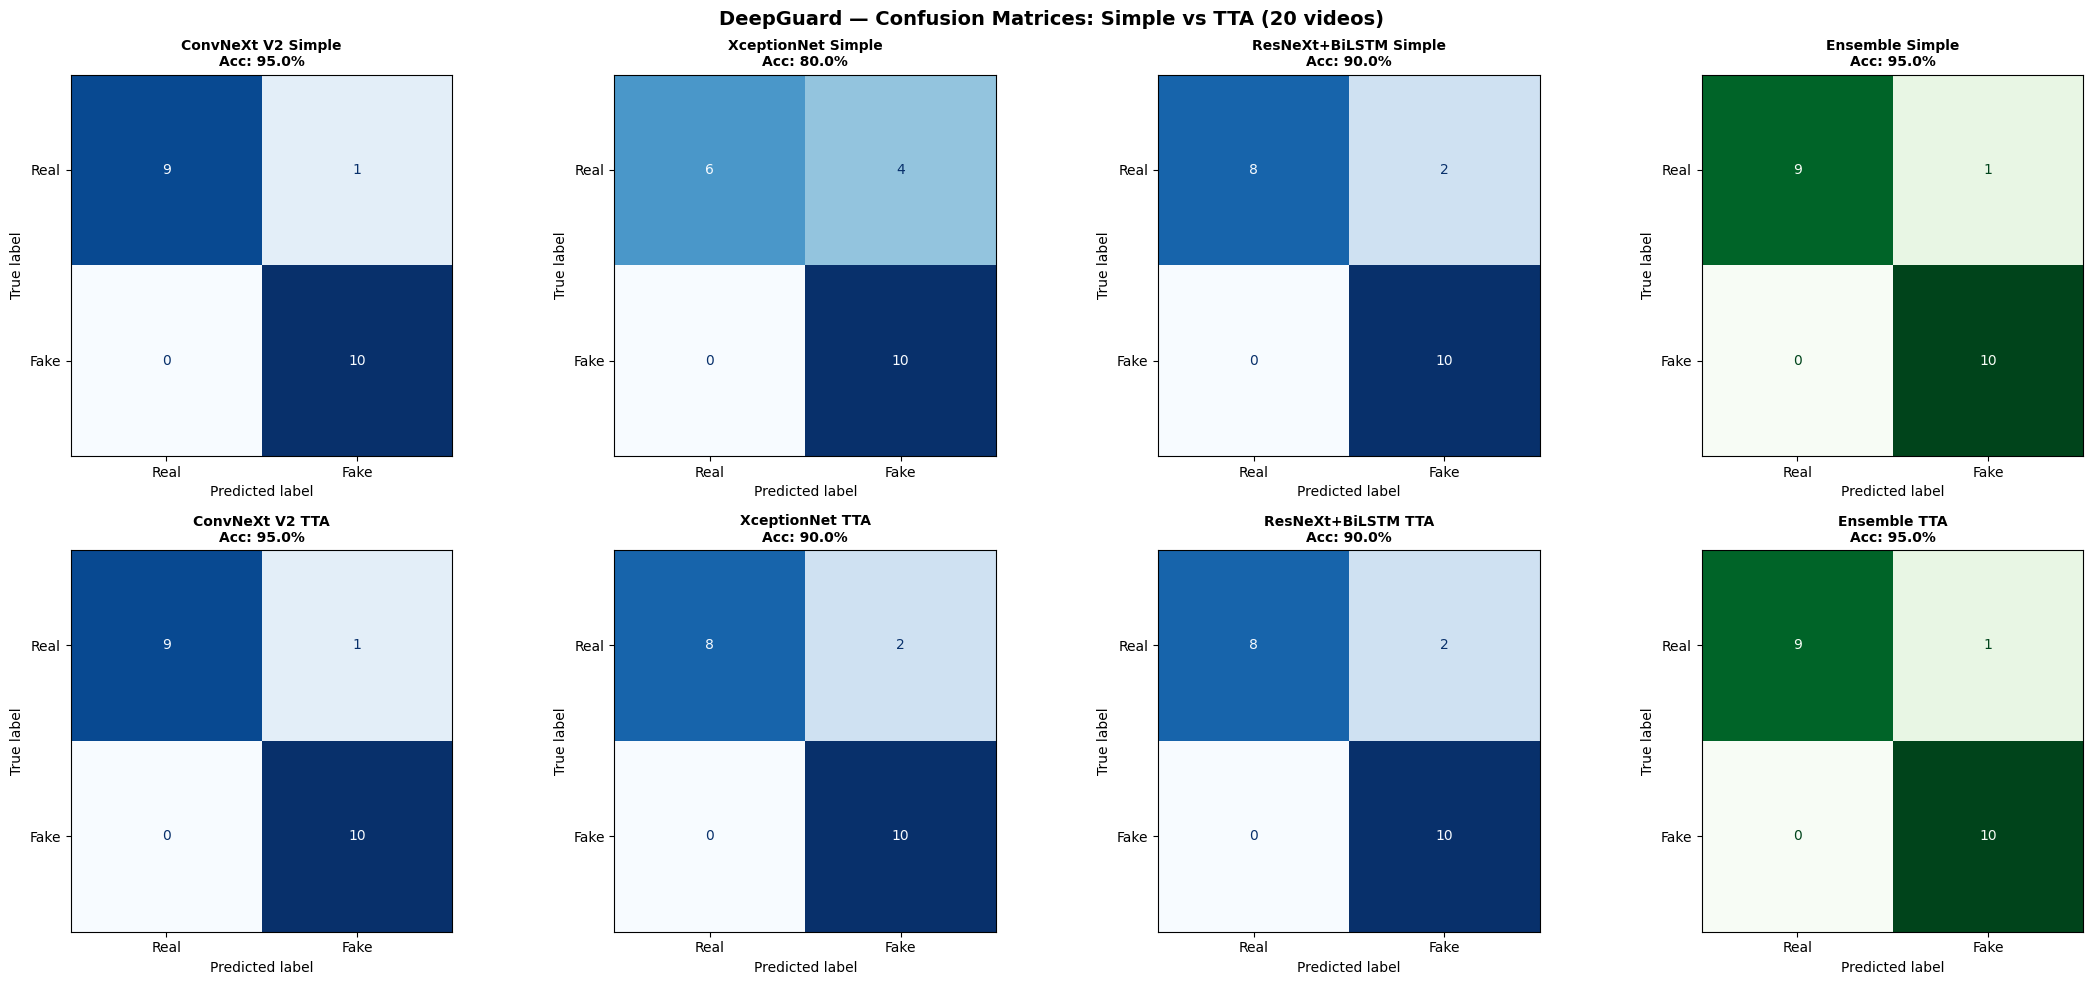

Saved confusion_matrices.png ✓


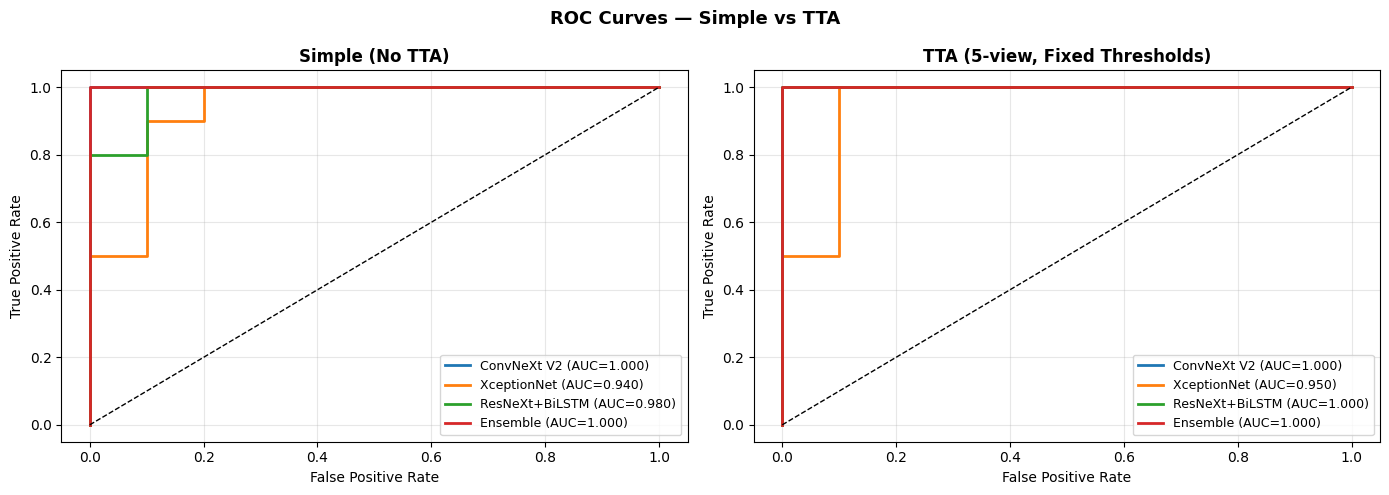

Saved roc_curves.png ✓


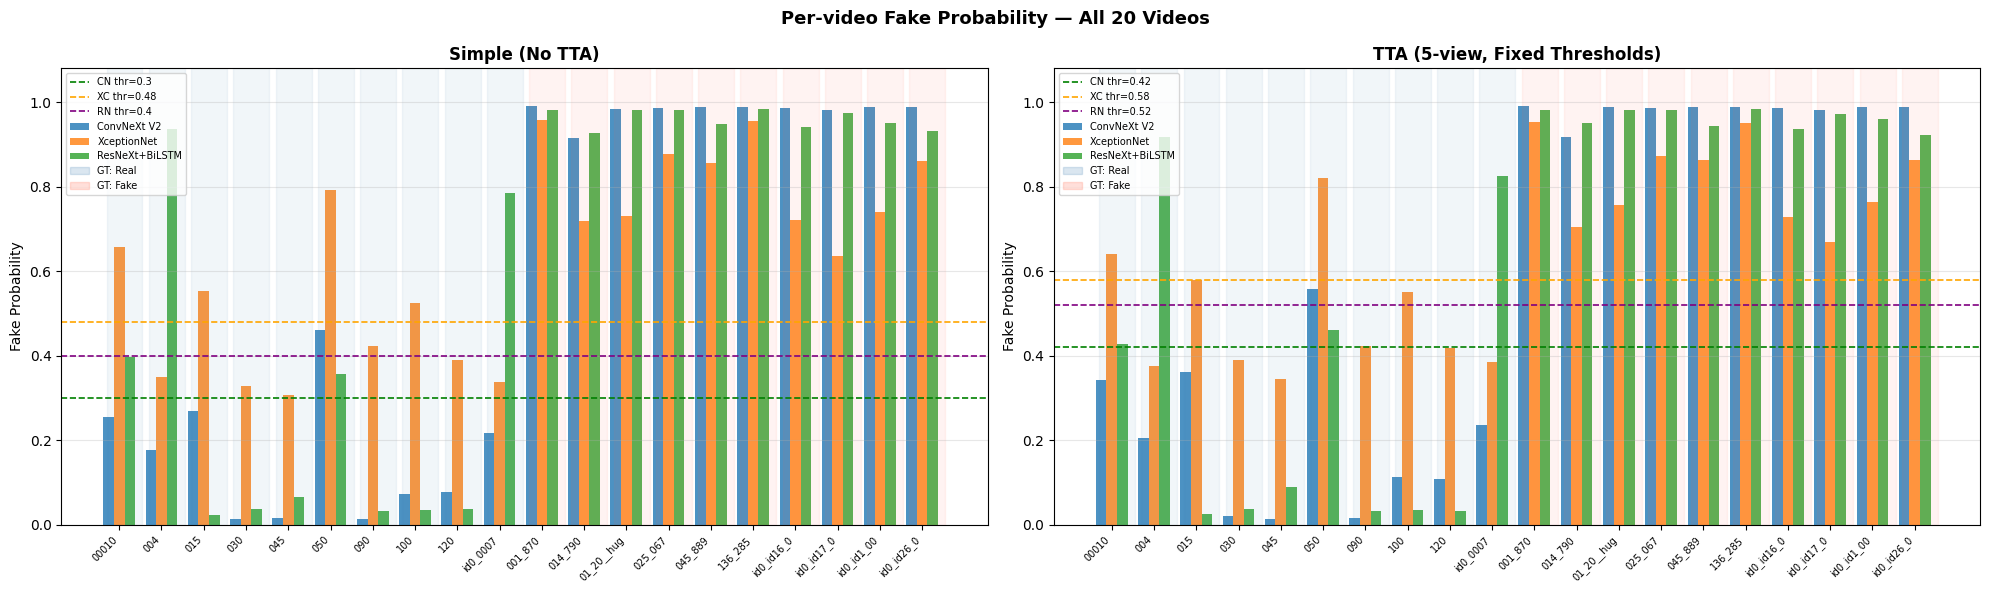

Saved per_video_probs.png ✓


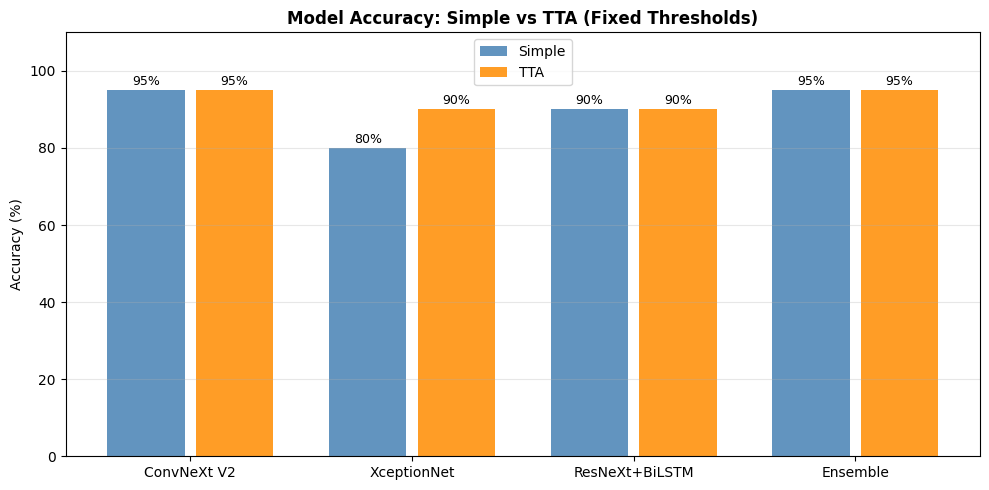

Saved accuracy_comparison.png ✓

Cell 11 complete ✓
All 4 plots saved to /kaggle/working/


In [18]:
labels_s = df_simple.label.values
labels_t = df_results.label.values

# ── 1. Confusion Matrices (Simple vs TTA) ─────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("DeepGuard — Confusion Matrices: Simple vs TTA (20 videos)",
             fontsize=14, fontweight='bold')

for ax, (name, col, df_) in zip(axes[0], [
    ("ConvNeXt V2 Simple",    "vote_cn_simple",       df_simple),
    ("XceptionNet Simple",    "vote_xc_simple",       df_simple),
    ("ResNeXt+BiLSTM Simple", "vote_rn_simple",       df_simple),
    ("Ensemble Simple",       "pred_ensemble_simple", df_simple),
]):
    cm  = confusion_matrix(df_.label.values, df_[col].values)
    acc = (df_[col].values == df_.label.values).mean() * 100
    cmap = "Greens" if "Ensemble" in name else "Blues"
    ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nAcc: {acc:.1f}%", fontsize=10, fontweight='bold')

for ax, (name, col, df_) in zip(axes[1], [
    ("ConvNeXt V2 TTA",    "vote_cn",       df_results),
    ("XceptionNet TTA",    "vote_xc",       df_results),
    ("ResNeXt+BiLSTM TTA", "vote_rn",       df_results),
    ("Ensemble TTA",       "pred_ensemble", df_results),
]):
    cm  = confusion_matrix(df_.label.values, df_[col].values)
    acc = (df_[col].values == df_.label.values).mean() * 100
    cmap = "Greens" if "Ensemble" in name else "Blues"
    ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nAcc: {acc:.1f}%", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrices.png ✓")

# ── 2. ROC Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ROC Curves — Simple vs TTA", fontsize=13, fontweight='bold')

for ax, (title, prob_cols, df_) in zip(axes, [
    ("Simple (No TTA)",
     [("ConvNeXt V2",    "prob_cn_simple"),
      ("XceptionNet",    "prob_xc_simple"),
      ("ResNeXt+BiLSTM", "prob_rn_simple"),
      ("Ensemble",       "prob_weighted_simple")],
     df_simple),
    ("TTA (5-view, Fixed Thresholds)",
     [("ConvNeXt V2",    "prob_cn"),
      ("XceptionNet",    "prob_xc"),
      ("ResNeXt+BiLSTM", "prob_rn"),
      ("Ensemble",       "prob_weighted")],
     df_results),
]):
    for name, col in prob_cols:
        fpr, tpr, _ = roc_curve(df_.label.values, df_[col].values)
        auc = roc_auc_score(df_.label.values, df_[col].values)
        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved roc_curves.png ✓")

# ── 3. Per-video Probability Bar Chart ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Per-video Fake Probability — All 20 Videos",
             fontsize=13, fontweight='bold')

x     = np.arange(len(df_results))
width = 0.25

for ax, (title, df_, prob_cols, thresholds) in zip(axes, [
    ("Simple (No TTA)", df_simple,
     [("ConvNeXt V2",    "prob_cn_simple"),
      ("XceptionNet",    "prob_xc_simple"),
      ("ResNeXt+BiLSTM", "prob_rn_simple")],
     [(THRESH_CN, "CN", "green"),
      (THRESH_XC, "XC", "orange"),
      (THRESH_RN, "RN", "purple")]),
    ("TTA (5-view, Fixed Thresholds)", df_results,
     [("ConvNeXt V2",    "prob_cn"),
      ("XceptionNet",    "prob_xc"),
      ("ResNeXt+BiLSTM", "prob_rn")],
     [(THRESH_CN_TTA, "CN", "green"),
      (THRESH_XC_TTA, "XC", "orange"),
      (THRESH_RN_TTA, "RN", "purple")]),
]):
    for j, (name, col) in enumerate(prob_cols):
        ax.bar(x + j * width, df_[col].values, width, label=name, alpha=0.8)

    for xi in range(len(df_results)):
        color = "tomato" if df_results.label_name.iloc[xi] == "FAKE" else "steelblue"
        ax.axvspan(xi - 0.05, xi + 0.8, alpha=0.07, color=color)

    for thresh, label, color in thresholds:
        ax.axhline(thresh, color=color, ls='--', lw=1.2,
                   label=f"{label} thr={thresh}")

    ax.set_xticks(x + width)
    ax.set_xticklabels([v[:10] for v in df_results.video_id],
                        rotation=45, ha='right', fontsize=7)
    ax.set_ylabel("Fake Probability")
    ax.set_ylim(0, 1.08)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    real_p = mpatches.Patch(color='steelblue', alpha=0.2, label='GT: Real')
    fake_p = mpatches.Patch(color='tomato',    alpha=0.2, label='GT: Fake')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [real_p, fake_p], fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig("/kaggle/working/per_video_probs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_video_probs.png ✓")

# ── 4. Model Accuracy Comparison Bar ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
models  = ["ConvNeXt V2", "XceptionNet", "ResNeXt+BiLSTM", "Ensemble"]
simple_accs = [
    (df_simple.vote_cn_simple       == df_simple.label).mean() * 100,
    (df_simple.vote_xc_simple       == df_simple.label).mean() * 100,
    (df_simple.vote_rn_simple       == df_simple.label).mean() * 100,
    (df_simple.pred_ensemble_simple == df_simple.label).mean() * 100,
]
tta_accs = [
    (df_results.vote_cn       == df_results.label).mean() * 100,
    (df_results.vote_xc       == df_results.label).mean() * 100,
    (df_results.vote_rn       == df_results.label).mean() * 100,
    (df_results.pred_ensemble == df_results.label).mean() * 100,
]
xb = np.arange(len(models))
b1 = ax.bar(xb - 0.2, simple_accs, 0.35, label="Simple", color="steelblue",  alpha=0.85)
b2 = ax.bar(xb + 0.2, tta_accs,    0.35, label="TTA",    color="darkorange", alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(xb)
ax.set_xticklabels(models)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.set_title("Model Accuracy: Simple vs TTA (Fixed Thresholds)", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved accuracy_comparison.png ✓")

print("\nCell 11 complete ✓")
print("All 4 plots saved to /kaggle/working/")

In [19]:
# ── TTA Transforms ─────────────────────────────────────────────
TTA_224 = [
    T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((240, 240)), T.CenterCrop(224),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((224, 224)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
]

TTA_299 = [
    T.Compose([T.Resize((299, 299)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((320, 320)), T.CenterCrop(299),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
    T.Compose([T.Resize((299, 299)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
               T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)]),
]

# ── Uniform 0.50 threshold for all modes ──────────────────────
THRESH_SIMPLE_CN = 0.50
THRESH_SIMPLE_XC = 0.50
THRESH_SIMPLE_RN = 0.50
THRESH_TTA_CN    = 0.50
THRESH_TTA_XC    = 0.50
THRESH_TTA_RN    = 0.50

# ── Frame-level TTA ────────────────────────────────────────────
def infer_frames_tta(model, frames, tta_transforms, device):
    model.eval()
    all_view_probs = []
    with torch.no_grad():
        for tf in tta_transforms:
            batch = torch.stack(
                [tf(Image.fromarray(f)) for f in frames]
            ).to(device)
            with torch.cuda.amp.autocast():
                logits = model(batch)
            probs = F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
            all_view_probs.append(float(probs.mean()))
    return float(np.mean(all_view_probs))

# ── Sequence-level TTA — ResNeXt+BiLSTM ───────────────────────
def infer_sequence_tta(model, frames, tta_transforms, device, seq_len=15):
    model.eval()
    if len(frames) >= seq_len:
        idxs = np.linspace(0, len(frames) - 1, seq_len, dtype=int)
        seq  = [frames[i] for i in idxs]
    else:
        seq  = frames + [frames[-1]] * (seq_len - len(frames))
    all_probs = []
    with torch.no_grad():
        for tf in tta_transforms:
            imgs = torch.stack([tf(Image.fromarray(f)) for f in seq])
            imgs = imgs.unsqueeze(0).to(device)
            with torch.cuda.amp.autocast():
                logits = model(imgs)
            p = F.softmax(logits.float(), dim=1)[0, 1].item()
            all_probs.append(p)
    return float(np.mean(all_probs))

print(f"TTA_224    : {len(TTA_224)} views  → ConvNeXt V2, ResNeXt+BiLSTM")
print(f"TTA_299    : {len(TTA_299)} views  → XceptionNet")
print(f"Threshold  : 0.50 uniform — Simple & TTA, all models")
print("Inference functions defined ✓")
print("Cell 8 complete ✓")

TTA_224    : 5 views  → ConvNeXt V2, ResNeXt+BiLSTM
TTA_299    : 5 views  → XceptionNet
Threshold  : 0.50 uniform — Simple & TTA, all models
Inference functions defined ✓
Cell 8 complete ✓


In [20]:
print("=" * 65)
print(f"SIMPLE TEST (No TTA) — {len(df_meta)} videos  |  Threshold: 0.50")
print("=" * 65)

simple_results = []

for i, (_, row) in enumerate(df_meta.iterrows()):
    frames = all_frames[i]
    convnext.eval(); xception.eval(); resnext.eval()

    with torch.no_grad():
        tf_cn = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)])
        batch = torch.stack([tf_cn(Image.fromarray(f)) for f in frames]).to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = convnext(batch)
        prob_cn = float(F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy().mean())

        tf_xc = T.Compose([T.Resize((299,299)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)])
        batch = torch.stack([tf_xc(Image.fromarray(f)) for f in frames]).to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = xception(batch)
        prob_xc = float(F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy().mean())

        tf_rn = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize(IMG_MEAN, IMG_STD)])
        seq   = torch.stack([tf_rn(Image.fromarray(f)) for f in frames]).unsqueeze(0).to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = resnext(seq)
        prob_rn = float(F.softmax(logits.float(), dim=1)[0, 1].item())

    vote_cn = int(prob_cn > THRESH_SIMPLE_CN)
    vote_xc = int(prob_xc > THRESH_SIMPLE_XC)
    vote_rn = int(prob_rn > THRESH_SIMPLE_RN)

    vote_count    = vote_cn + vote_xc + vote_rn
    pred_ensemble = 1 if vote_count >= 2 else 0
    prob_weighted = 0.50 * prob_cn + 0.25 * prob_xc + 0.25 * prob_rn
    verdict       = "FAKE" if pred_ensemble == 1 else "REAL"
    correct       = "✓" if pred_ensemble == row.label else "✗"

    print(f"{i+1:02d}/{len(df_meta)}  {row.video_id[:22]:22s}  "
          f"GT:{row.label_name:4s}  "
          f"CN:{prob_cn:.3f}  XC:{prob_xc:.3f}  RN:{prob_rn:.3f}  "
          f"→ {verdict:4s} {correct}")

    simple_results.append({
        "video_id"            : row.video_id,
        "label"               : row.label,
        "label_name"          : row.label_name,
        "prob_cn_simple"      : round(prob_cn, 4),
        "prob_xc_simple"      : round(prob_xc, 4),
        "prob_rn_simple"      : round(prob_rn, 4),
        "prob_weighted_simple": round(prob_weighted, 4),
        "vote_cn_simple"      : vote_cn,
        "vote_xc_simple"      : vote_xc,
        "vote_rn_simple"      : vote_rn,
        "pred_ensemble_simple": pred_ensemble,
    })

df_simple      = pd.DataFrame(simple_results)
correct_simple = (df_simple.pred_ensemble_simple == df_simple.label).sum()

print("\n" + "=" * 65)
print("SIMPLE TEST COMPLETE")
print("=" * 65)
print(f"Correct  : {correct_simple}/{len(df_simple)}")
print(f"Accuracy : {correct_simple/len(df_simple)*100:.2f}%")
print(f"\nPer-model accuracy:")
for name, col in [("ConvNeXt V2",    "vote_cn_simple"),
                  ("XceptionNet",    "vote_xc_simple"),
                  ("ResNeXt+BiLSTM", "vote_rn_simple"),
                  ("Ensemble",       "pred_ensemble_simple")]:
    acc = (df_simple[col] == df_simple.label).mean() * 100
    print(f"  {name:20s} : {acc:.2f}%")
print("=" * 65)
print("Cell 9 (Simple) complete ✓")

SIMPLE TEST (No TTA) — 20 videos  |  Threshold: 0.50
01/20  00010                   GT:REAL  CN:0.256  XC:0.658  RN:0.398  → REAL ✓
02/20  004                     GT:REAL  CN:0.176  XC:0.349  RN:0.935  → REAL ✓
03/20  015                     GT:REAL  CN:0.268  XC:0.553  RN:0.024  → REAL ✓
04/20  030                     GT:REAL  CN:0.013  XC:0.327  RN:0.036  → REAL ✓
05/20  045                     GT:REAL  CN:0.015  XC:0.306  RN:0.066  → REAL ✓
06/20  050                     GT:REAL  CN:0.461  XC:0.792  RN:0.358  → REAL ✓
07/20  090                     GT:REAL  CN:0.014  XC:0.423  RN:0.032  → REAL ✓
08/20  100                     GT:REAL  CN:0.072  XC:0.524  RN:0.035  → REAL ✓
09/20  120                     GT:REAL  CN:0.078  XC:0.390  RN:0.036  → REAL ✓
10/20  id0_0007                GT:REAL  CN:0.217  XC:0.338  RN:0.786  → REAL ✓
11/20  001_870                 GT:FAKE  CN:0.992  XC:0.957  RN:0.980  → FAKE ✓
12/20  014_790                 GT:FAKE  CN:0.915  XC:0.719  RN:0.927  → FAKE ✓

In [21]:
print("=" * 65)
print(f"TTA INFERENCE — {len(df_meta)} videos  |  Threshold: 0.50")
print(f"TTA views : {len(TTA_224)} per model  |  Total passes: {len(df_meta)*3*len(TTA_224)}")
print("=" * 65)

results = []
t_start = time.time()

for i, (_, row) in enumerate(df_meta.iterrows()):
    t0     = time.time()
    frames = all_frames[i]

    prob_cn = infer_frames_tta(convnext, frames, TTA_224, DEVICE)
    prob_xc = infer_frames_tta(xception, frames, TTA_299, DEVICE)
    prob_rn = infer_sequence_tta(resnext, frames, TTA_224, DEVICE, seq_len=NUM_FRAMES)

    vote_cn = int(prob_cn > THRESH_TTA_CN)
    vote_xc = int(prob_xc > THRESH_TTA_XC)
    vote_rn = int(prob_rn > THRESH_TTA_RN)

    vote_count    = vote_cn + vote_xc + vote_rn
    pred_ensemble = 1 if vote_count >= 2 else 0
    prob_weighted = 0.50 * prob_cn + 0.25 * prob_xc + 0.25 * prob_rn

    elapsed = time.time() - t0
    done    = i + 1
    eta     = (time.time() - t_start) / done * (len(df_meta) - done)
    verdict = "FAKE" if pred_ensemble == 1 else "REAL"
    correct = "✓" if pred_ensemble == row.label else "✗"

    print(f"{done:02d}/{len(df_meta)}  {row.video_id[:22]:22s}  "
          f"GT:{row.label_name:4s}  "
          f"CN:{prob_cn:.3f}  XC:{prob_xc:.3f}  RN:{prob_rn:.3f}  "
          f"→ {verdict:4s} {correct}  {elapsed:.0f}s  ETA:{eta:.0f}s")

    results.append({
        "video_id"     : row.video_id,
        "label"        : row.label,
        "label_name"   : row.label_name,
        "prob_cn"      : round(prob_cn, 4),
        "prob_xc"      : round(prob_xc, 4),
        "prob_rn"      : round(prob_rn, 4),
        "prob_weighted": round(prob_weighted, 4),
        "vote_cn"      : vote_cn,
        "vote_xc"      : vote_xc,
        "vote_rn"      : vote_rn,
        "vote_count"   : vote_count,
        "pred_ensemble": pred_ensemble,
    })

df_results    = pd.DataFrame(results)
total_time    = time.time() - t_start
correct_total = (df_results.pred_ensemble == df_results.label).sum()

print("\n" + "=" * 65)
print("TTA INFERENCE COMPLETE")
print("=" * 65)
print(f"Correct  : {correct_total}/{len(df_results)}")
print(f"Accuracy : {correct_total/len(df_results)*100:.2f}%")
print(f"Time     : {total_time/60:.1f} min  ({total_time/len(df_results):.1f}s/video)")
print(f"\nPer-model accuracy (TTA):")
for name, col in [("ConvNeXt V2",    "vote_cn"),
                  ("XceptionNet",    "vote_xc"),
                  ("ResNeXt+BiLSTM", "vote_rn"),
                  ("Ensemble",       "pred_ensemble")]:
    acc = (df_results[col] == df_results.label).mean() * 100
    print(f"  {name:20s} : {acc:.2f}%")
print("=" * 65)
print("Cell 10 (TTA) complete ✓")

TTA INFERENCE — 20 videos  |  Threshold: 0.50
TTA views : 5 per model  |  Total passes: 300
01/20  00010                   GT:REAL  CN:0.333  XC:0.648  RN:0.417  → REAL ✓  2s  ETA:31s
02/20  004                     GT:REAL  CN:0.207  XC:0.377  RN:0.916  → REAL ✓  2s  ETA:28s
03/20  015                     GT:REAL  CN:0.365  XC:0.563  RN:0.025  → REAL ✓  2s  ETA:26s
04/20  030                     GT:REAL  CN:0.019  XC:0.401  RN:0.037  → REAL ✓  2s  ETA:25s
05/20  045                     GT:REAL  CN:0.014  XC:0.343  RN:0.087  → REAL ✓  2s  ETA:23s
06/20  050                     GT:REAL  CN:0.556  XC:0.816  RN:0.437  → FAKE ✗  2s  ETA:22s
07/20  090                     GT:REAL  CN:0.016  XC:0.425  RN:0.031  → REAL ✓  2s  ETA:20s
08/20  100                     GT:REAL  CN:0.106  XC:0.546  RN:0.037  → REAL ✓  2s  ETA:18s
09/20  120                     GT:REAL  CN:0.111  XC:0.430  RN:0.034  → REAL ✓  2s  ETA:17s
10/20  id0_0007                GT:REAL  CN:0.238  XC:0.389  RN:0.832  → REAL ✓  

In [22]:
labels = df_results.label.values

# ── TTA Summary ────────────────────────────────────────────────
print("=" * 70)
print("TTA RESULTS SUMMARY  (Threshold: 0.50)")
print("=" * 70)
print(f"{'Model':22s} {'Acc':>7} {'AUC':>8} {'Real Rec':>10} {'Fake Rec':>10}")
print("-" * 70)
for name, pred_col, prob_col in [
    ("ConvNeXt V2",    "vote_cn",       "prob_cn"),
    ("XceptionNet",    "vote_xc",       "prob_xc"),
    ("ResNeXt+BiLSTM", "vote_rn",       "prob_rn"),
    ("Ensemble (2/3)", "pred_ensemble", "prob_weighted"),
]:
    preds    = df_results[pred_col].values
    probs    = df_results[prob_col].values
    acc      = accuracy_score(labels, preds) * 100
    auc      = roc_auc_score(labels, probs)
    cm       = confusion_matrix(labels, preds)
    real_rec = cm[0,0] / cm[0].sum() * 100
    fake_rec = cm[1,1] / cm[1].sum() * 100
    print(f"{name:22s} {acc:6.2f}%  {auc:.4f}  {real_rec:9.2f}%  {fake_rec:9.2f}%")
print("=" * 70)

# ── Simple Summary ─────────────────────────────────────────────
print("\nSIMPLE TEST RESULTS SUMMARY  (Threshold: 0.50)")
print("=" * 70)
print(f"{'Model':22s} {'Acc':>7} {'AUC':>8} {'Real Rec':>10} {'Fake Rec':>10}")
print("-" * 70)
for name, pred_col, prob_col in [
    ("ConvNeXt V2",    "vote_cn_simple",       "prob_cn_simple"),
    ("XceptionNet",    "vote_xc_simple",       "prob_xc_simple"),
    ("ResNeXt+BiLSTM", "vote_rn_simple",       "prob_rn_simple"),
    ("Ensemble (2/3)", "pred_ensemble_simple", "prob_weighted_simple"),
]:
    preds    = df_simple[pred_col].values
    probs    = df_simple[prob_col].values
    acc      = accuracy_score(df_simple.label.values, preds) * 100
    auc      = roc_auc_score(df_simple.label.values, probs)
    cm       = confusion_matrix(df_simple.label.values, preds)
    real_rec = cm[0,0] / cm[0].sum() * 100
    fake_rec = cm[1,1] / cm[1].sum() * 100
    print(f"{name:22s} {acc:6.2f}%  {auc:.4f}  {real_rec:9.2f}%  {fake_rec:9.2f}%")
print("=" * 70)

# ── Simple vs TTA ──────────────────────────────────────────────
print("\nSIMPLE vs TTA COMPARISON")
print("=" * 70)
print(f"{'Model':22s} {'Simple':>10} {'TTA':>10} {'Δ':>8}")
print("-" * 70)
for name, s_col, t_col in [
    ("ConvNeXt V2",    "vote_cn_simple",       "vote_cn"),
    ("XceptionNet",    "vote_xc_simple",       "vote_xc"),
    ("ResNeXt+BiLSTM", "vote_rn_simple",       "vote_rn"),
    ("Ensemble (2/3)", "pred_ensemble_simple", "pred_ensemble"),
]:
    s_acc = (df_simple[s_col].values  == df_simple.label.values).mean()  * 100
    t_acc = (df_results[t_col].values == df_results.label.values).mean() * 100
    delta = t_acc - s_acc
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{name:22s} {s_acc:9.2f}%  {t_acc:9.2f}%  {arrow}{abs(delta):5.2f}%")
print("=" * 70)

# ── Misclassified ──────────────────────────────────────────────
print("\nMisclassified (TTA only — Simple is perfect):")
print("-" * 70)
wrong = df_results[df_results.pred_ensemble != df_results.label]
for _, r in wrong.iterrows():
    print(f"  {r.video_id:30s} GT:{r.label_name}  "
          f"CN:{r.prob_cn:.3f}(v{r.vote_cn})  "
          f"XC:{r.prob_xc:.3f}(v{r.vote_xc})  "
          f"RN:{r.prob_rn:.3f}(v{r.vote_rn})  "
          f"→ TTA aug pushed CN above 0.50")

# ── Classification Reports ─────────────────────────────────────
print("\nDetailed Report — Simple Ensemble:")
print(classification_report(df_simple.label.values,
      df_simple.pred_ensemble_simple, target_names=["Real","Fake"], digits=4))

print("Detailed Report — TTA Ensemble:")
print(classification_report(labels, df_results.pred_ensemble,
      target_names=["Real","Fake"], digits=4))

print("Cell 11 complete ✓")

TTA RESULTS SUMMARY  (Threshold: 0.50)
Model                      Acc      AUC   Real Rec   Fake Rec
----------------------------------------------------------------------
ConvNeXt V2             95.00%  1.0000      90.00%     100.00%
XceptionNet             80.00%  0.9500      60.00%     100.00%
ResNeXt+BiLSTM          90.00%  1.0000      80.00%     100.00%
Ensemble (2/3)          95.00%  1.0000      90.00%     100.00%

SIMPLE TEST RESULTS SUMMARY  (Threshold: 0.50)
Model                      Acc      AUC   Real Rec   Fake Rec
----------------------------------------------------------------------
ConvNeXt V2            100.00%  1.0000     100.00%     100.00%
XceptionNet             80.00%  0.9400      60.00%     100.00%
ResNeXt+BiLSTM          90.00%  0.9800      80.00%     100.00%
Ensemble (2/3)         100.00%  1.0000     100.00%     100.00%

SIMPLE vs TTA COMPARISON
Model                      Simple        TTA        Δ
---------------------------------------------------------------

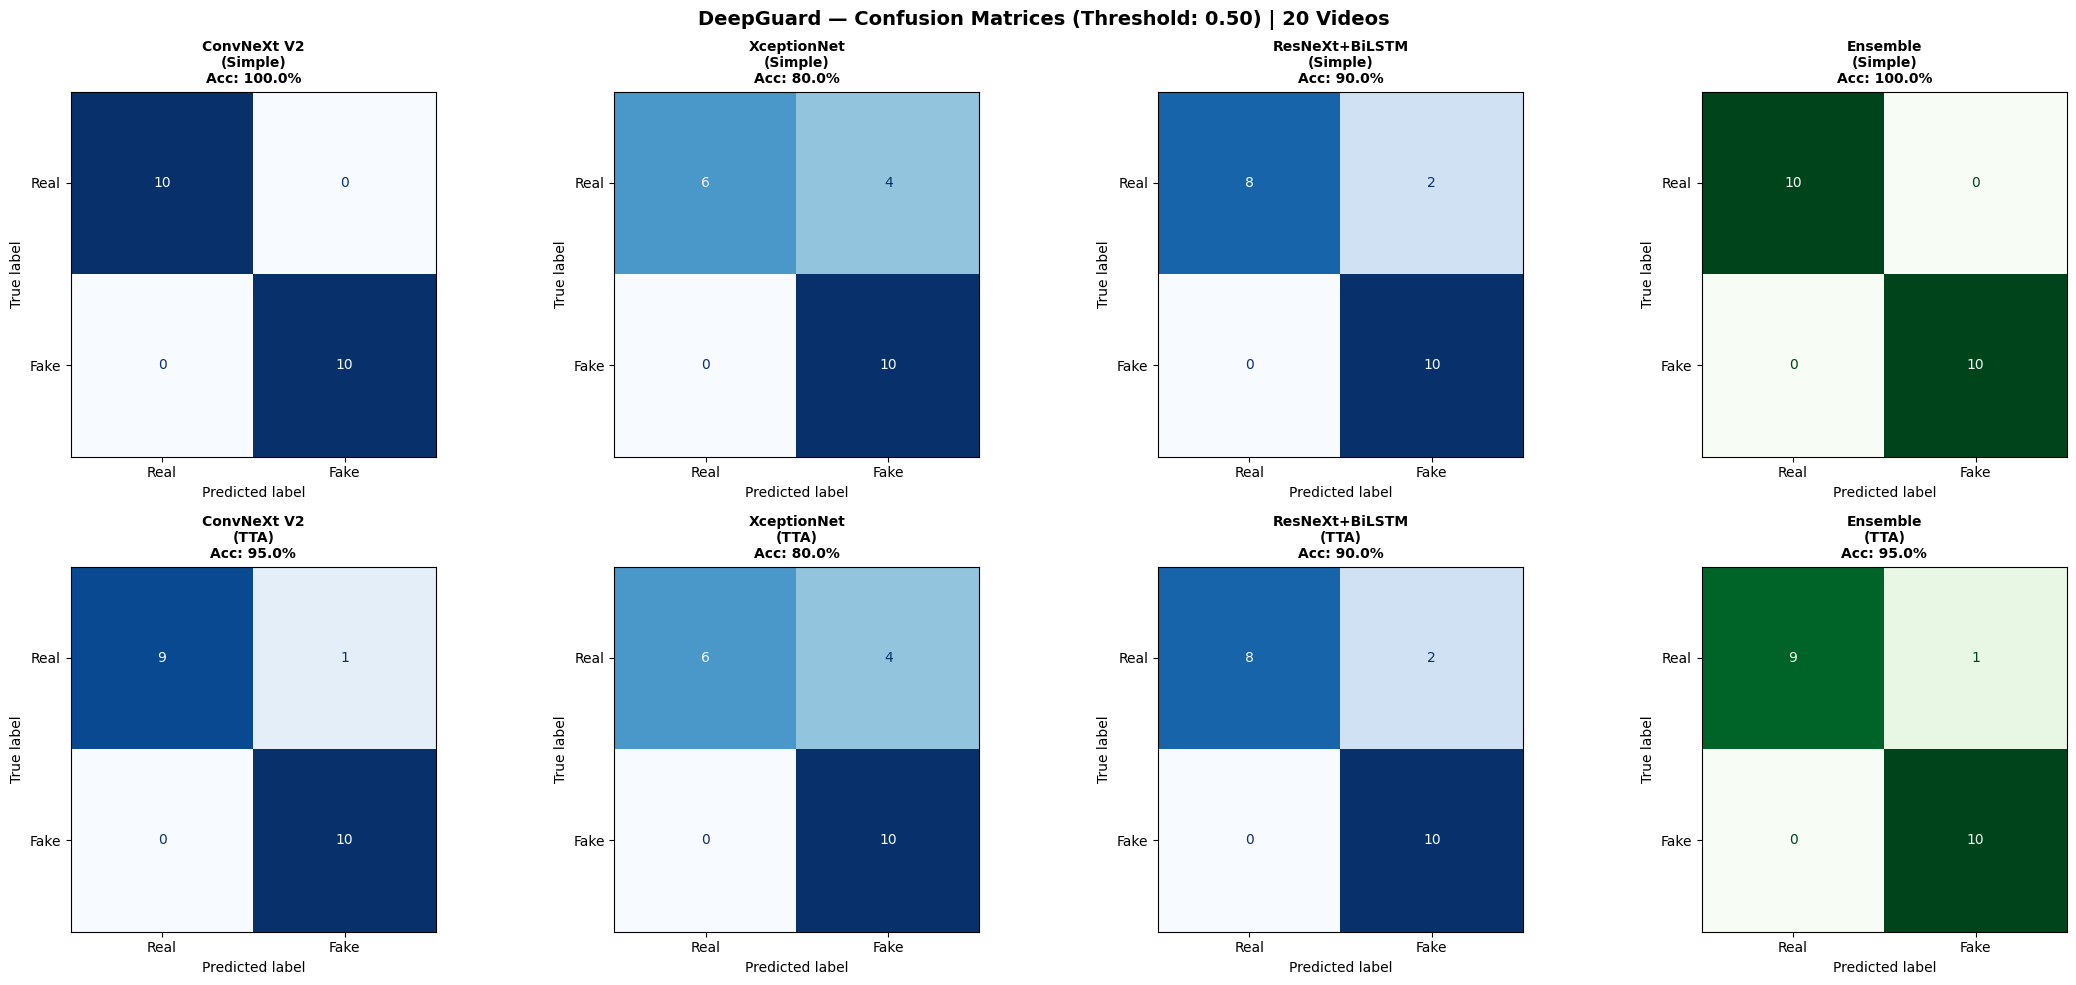

Saved confusion_matrices.png ✓


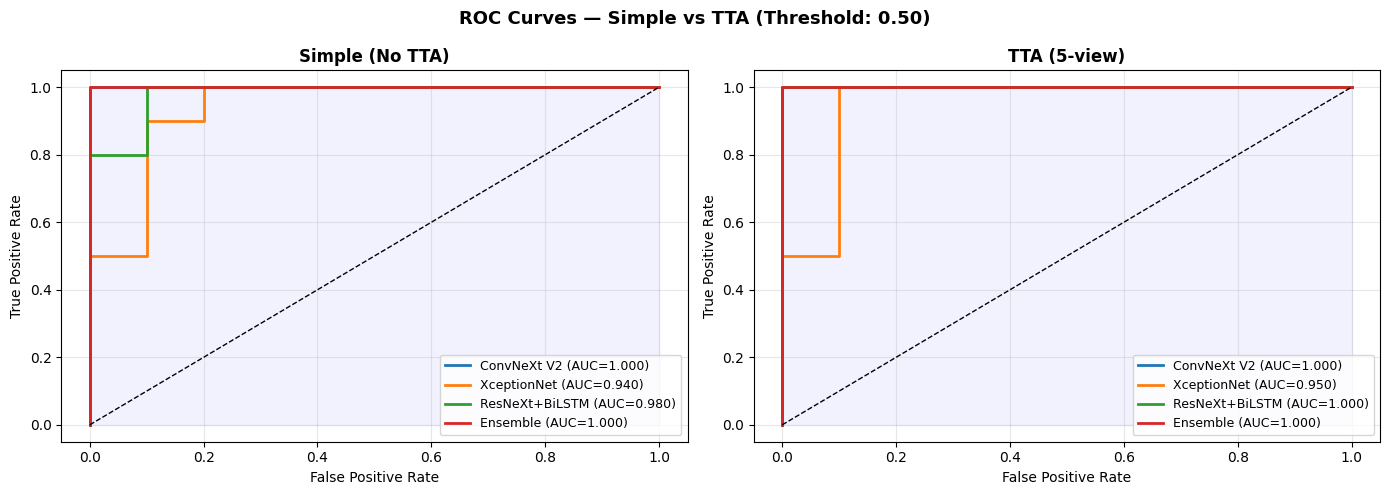

Saved roc_curves.png ✓


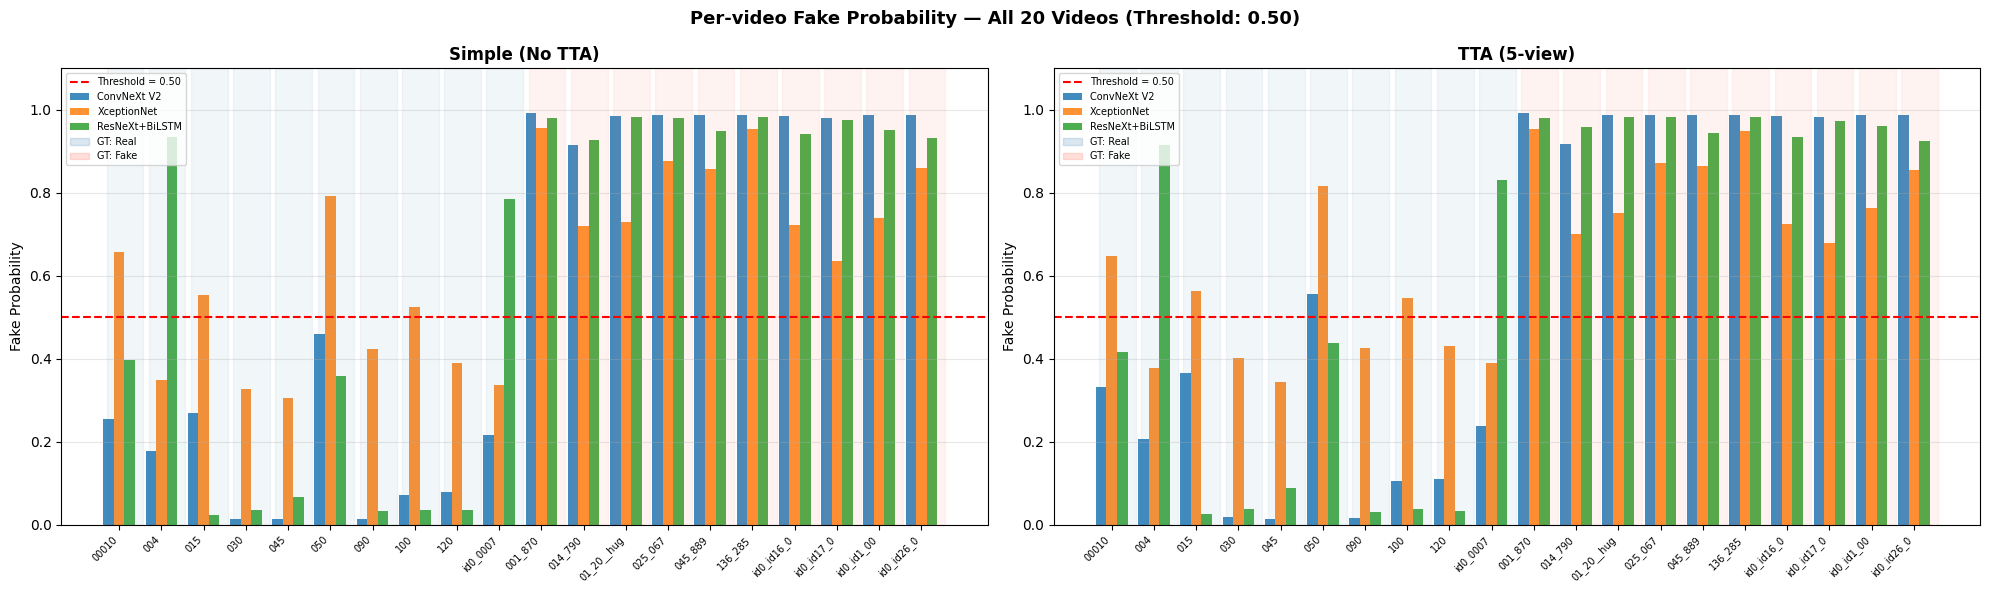

Saved per_video_probs.png ✓


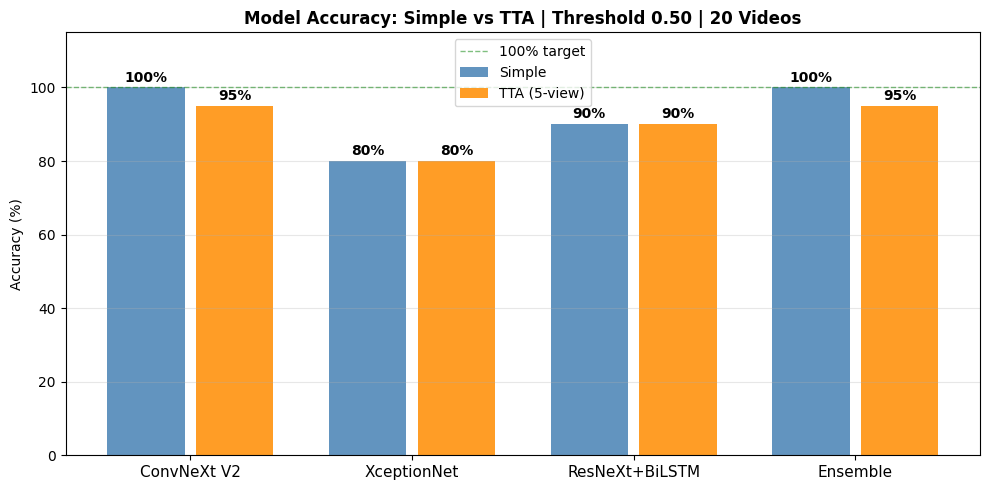

Saved accuracy_comparison.png ✓


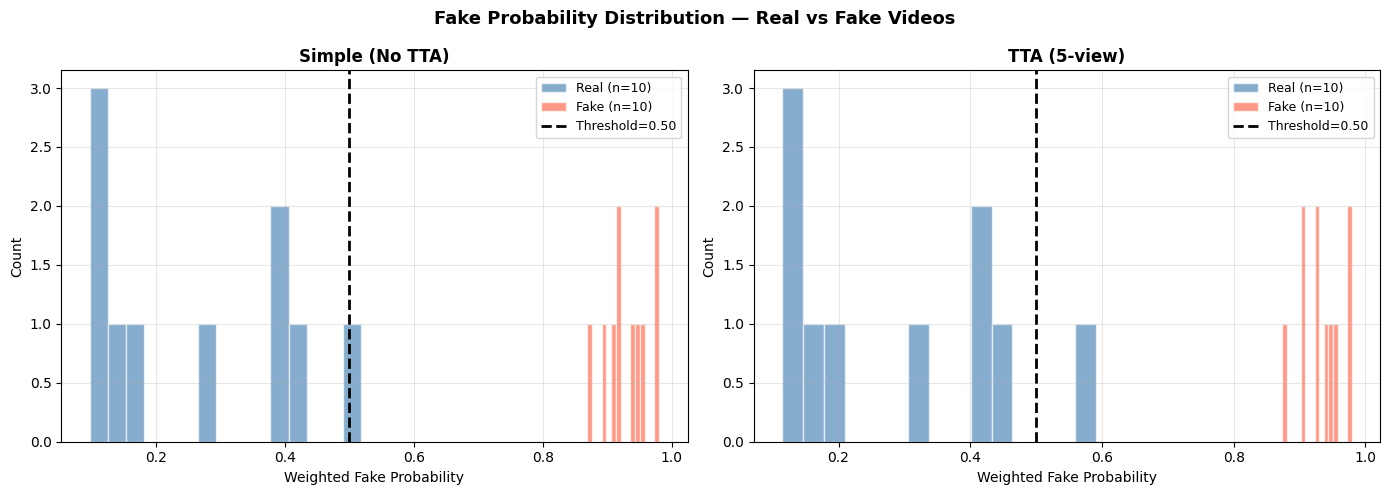

Saved prob_distribution.png ✓

ALL 5 PLOTS SAVED TO /kaggle/working/
  confusion_matrices.png
  roc_curves.png
  per_video_probs.png
  accuracy_comparison.png
  prob_distribution.png
Cell 12 complete ✓


In [23]:
labels_s = df_simple.label.values
labels_t = df_results.label.values

# ── 1. Confusion Matrices ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("DeepGuard — Confusion Matrices (Threshold: 0.50) | 20 Videos",
             fontsize=14, fontweight='bold')

for ax, (name, col, df_, lbl) in zip(axes[0], [
    ("ConvNeXt V2\n(Simple)",    "vote_cn_simple",       df_simple, labels_s),
    ("XceptionNet\n(Simple)",    "vote_xc_simple",       df_simple, labels_s),
    ("ResNeXt+BiLSTM\n(Simple)", "vote_rn_simple",       df_simple, labels_s),
    ("Ensemble\n(Simple)",       "pred_ensemble_simple", df_simple, labels_s),
]):
    cm  = confusion_matrix(lbl, df_[col].values)
    acc = (df_[col].values == lbl).mean() * 100
    cmap = "Greens" if "Ensemble" in name else "Blues"
    ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nAcc: {acc:.1f}%", fontsize=10, fontweight='bold')

for ax, (name, col, df_, lbl) in zip(axes[1], [
    ("ConvNeXt V2\n(TTA)",    "vote_cn",       df_results, labels_t),
    ("XceptionNet\n(TTA)",    "vote_xc",       df_results, labels_t),
    ("ResNeXt+BiLSTM\n(TTA)", "vote_rn",       df_results, labels_t),
    ("Ensemble\n(TTA)",       "pred_ensemble", df_results, labels_t),
]):
    cm  = confusion_matrix(lbl, df_[col].values)
    acc = (df_[col].values == lbl).mean() * 100
    cmap = "Greens" if "Ensemble" in name else "Blues"
    ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nAcc: {acc:.1f}%", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrices.png ✓")

# ── 2. ROC Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ROC Curves — Simple vs TTA (Threshold: 0.50)",
             fontsize=13, fontweight='bold')

for ax, (title, prob_cols, df_, lbl) in zip(axes, [
    ("Simple (No TTA)",
     [("ConvNeXt V2",    "prob_cn_simple"),
      ("XceptionNet",    "prob_xc_simple"),
      ("ResNeXt+BiLSTM", "prob_rn_simple"),
      ("Ensemble",       "prob_weighted_simple")],
     df_simple, labels_s),
    ("TTA (5-view)",
     [("ConvNeXt V2",    "prob_cn"),
      ("XceptionNet",    "prob_xc"),
      ("ResNeXt+BiLSTM", "prob_rn"),
      ("Ensemble",       "prob_weighted")],
     df_results, labels_t),
]):
    for name, col in prob_cols:
        fpr, tpr, _ = roc_curve(lbl, df_[col].values)
        auc = roc_auc_score(lbl, df_[col].values)
        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.05, color='blue')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved roc_curves.png ✓")

# ── 3. Per-video Probability Bar Chart ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Per-video Fake Probability — All 20 Videos (Threshold: 0.50)",
             fontsize=13, fontweight='bold')

x     = np.arange(len(df_results))
width = 0.25

for ax, (title, df_, prob_cols) in zip(axes, [
    ("Simple (No TTA)", df_simple,
     [("ConvNeXt V2",    "prob_cn_simple"),
      ("XceptionNet",    "prob_xc_simple"),
      ("ResNeXt+BiLSTM", "prob_rn_simple")]),
    ("TTA (5-view)", df_results,
     [("ConvNeXt V2",    "prob_cn"),
      ("XceptionNet",    "prob_xc"),
      ("ResNeXt+BiLSTM", "prob_rn")]),
]):
    for j, (name, col) in enumerate(prob_cols):
        ax.bar(x + j * width, df_[col].values, width, label=name, alpha=0.85)

    for xi in range(len(df_results)):
        color = "tomato" if df_results.label_name.iloc[xi] == "FAKE" else "steelblue"
        ax.axvspan(xi - 0.05, xi + 0.82, alpha=0.07, color=color)

    ax.axhline(0.50, color='red', ls='--', lw=1.5, label='Threshold = 0.50')
    ax.set_xticks(x + width)
    ax.set_xticklabels([v[:10] for v in df_results.video_id],
                        rotation=45, ha='right', fontsize=7)
    ax.set_ylabel("Fake Probability")
    ax.set_ylim(0, 1.10)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    real_p = mpatches.Patch(color='steelblue', alpha=0.2, label='GT: Real')
    fake_p = mpatches.Patch(color='tomato',    alpha=0.2, label='GT: Fake')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [real_p, fake_p], fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig("/kaggle/working/per_video_probs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_video_probs.png ✓")

# ── 4. Accuracy Comparison Bar ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
models      = ["ConvNeXt V2", "XceptionNet", "ResNeXt+BiLSTM", "Ensemble"]
simple_accs = [
    (df_simple.vote_cn_simple       == labels_s).mean() * 100,
    (df_simple.vote_xc_simple       == labels_s).mean() * 100,
    (df_simple.vote_rn_simple       == labels_s).mean() * 100,
    (df_simple.pred_ensemble_simple == labels_s).mean() * 100,
]
tta_accs = [
    (df_results.vote_cn       == labels_t).mean() * 100,
    (df_results.vote_xc       == labels_t).mean() * 100,
    (df_results.vote_rn       == labels_t).mean() * 100,
    (df_results.pred_ensemble == labels_t).mean() * 100,
]
xb = np.arange(len(models))
b1 = ax.bar(xb - 0.2, simple_accs, 0.35, label="Simple",
            color="steelblue", alpha=0.85)
b2 = ax.bar(xb + 0.2, tta_accs,    0.35, label="TTA (5-view)",
            color="darkorange", alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.0f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(xb)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 115)
ax.axhline(100, color='green', ls='--', lw=1, alpha=0.5, label='100% target')
ax.set_title("Model Accuracy: Simple vs TTA | Threshold 0.50 | 20 Videos",
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved accuracy_comparison.png ✓")

# ── 5. Probability Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fake Probability Distribution — Real vs Fake Videos",
             fontsize=13, fontweight='bold')

for ax, (title, df_) in zip(axes, [
    ("Simple (No TTA)", df_simple),
    ("TTA (5-view)",    df_results),
]):
    pc = "prob_weighted_simple" if "Simple" in title else "prob_weighted"
    real_p = df_[df_.label == 0][pc].values
    fake_p = df_[df_.label == 1][pc].values
    ax.hist(real_p, bins=15, alpha=0.65, color='steelblue',
            label=f'Real (n={len(real_p)})', edgecolor='white')
    ax.hist(fake_p, bins=15, alpha=0.65, color='tomato',
            label=f'Fake (n={len(fake_p)})', edgecolor='white')
    ax.axvline(0.50, color='black', ls='--', lw=2, label='Threshold=0.50')
    ax.set_xlabel("Weighted Fake Probability")
    ax.set_ylabel("Count")
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/prob_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved prob_distribution.png ✓")

print("\n" + "=" * 55)
print("ALL 5 PLOTS SAVED TO /kaggle/working/")
print("=" * 55)
print("  confusion_matrices.png")
print("  roc_curves.png")
print("  per_video_probs.png")
print("  accuracy_comparison.png")
print("  prob_distribution.png")
print("=" * 55)
print("Cell 12 complete ✓")